# Computing SEDs from GADGET-4 simulated data

In [ ]:
#===== NOTE: General Information =====#
# The below pipeline / code blocks are designed to compute "Spectral Energy Distributions" (SEDs).
# It is adapted to work with the output of Osaka GASDGET-4 comsmological data.

# Furthermore, it uses a specific file system

# Author: Lennart Rathjen

In [4]:
#===== NOTE: Imports =====#
import os
import glob
import re
import shutil
import time
from pathlib import Path

import astropy.units as u
import fsps
import h5py
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from astropy.cosmology import FlatLambdaCDM, LambdaCDM
from tqdm import tqdm

# (1) Data Preperation

In [2]:
#===== Main Function =====#
# region Main Function

#=== Snapshot Recognition ===#
# Relative Path to the simulation data directories (snapdir_XXX / groups_XXX)
BASEPATH = "../../BigData/"
def detect_all_snapnums(basepath):
    """
    Searches the base directory for snapshot and gorups folders, 
    and returns a sorted list of all snapshot numbers found.
    Expects folder names in the format: snapdir_XXX and groups_XXX.
    """
    snapnums = []
    for name in os.listdir(basepath):
        # Search the right folders
        m = re.match(r"(snapdir|groups)_(\d{3})", name)
        if m:
            snapnums.append(int(m.group(2)))
    # Discard duplicates
    return sorted(set(snapnums))

#=== Load Data ===#
def load_all_groups_for_snapnum(basepath, snapnum):
    """
    Loads all HDF5 group files (FoF/ Subhalo catalog) for a given snapshot.
    Expects files in the following format: fof_subhalo_tab_XXX.*.hdf5.
    Returns a list of open h5py.File objects.
    """
    groupdir = os.path.join(basepath, f"groups_{snapnum:03d}")
    files = []
    for fname in sorted(os.listdir(groupdir)):
        if fname.startswith(f"fof_subhalo_tab_{snapnum:03d}") and fname.endswith(".hdf5"):
            files.append(h5py.File(os.path.join(groupdir, fname), "r"))
    return files

def load_all_snapshots_for_snapnum(basepath, snapnum):
    """
    Loads all HDF5 snapshot files (particle data) for a given snapshot.
    Expects files in the following format: snapshot_XXX.*.hdf5
    Returns a list of open h5py.File objects.
    """
    snapdir = os.path.join(basepath, f"snapdir_{snapnum:03d}")
    files = []
    for fname in sorted(os.listdir(snapdir)):
        if fname.startswith(f"snapshot_{snapnum:03d}") and fname.endswith(".hdf5"):
            files.append(h5py.File(os.path.join(snapdir, fname), "r"))
    return files

#=== Data Merging ===#
def merge_group_subhalos(group_files):
    """
    Reads subhalo properties from all group files and combnes them into contiguous arrays.

    Return:
        M_halo   – Subhalo-Total masses             [GADGET-4 Units]
        N_type   – Number of particles per type     [N_subhalos x 6]
        Off_type – Particle-Offset per Type         [N_subhalos x 6]
        pos      – Subhalo-Positions                (absolute, Redshift Z) [N_subhalos x 3]
    """
    subhalo_masses = []
    lentype  = []
    offtype  = []
    positions = []

    for f in group_files:
        sub = f["Subhalo"]
        subhalo_masses.append(sub["SubhaloMass"][:])
        lentype.append(sub["SubhaloLenType"][:])
        offtype.append(sub["SubhaloOffsetType"][:])
        positions.append(sub["SubhaloPos"][:])      # Absolute Position at Redshift Z

    N_type   = np.concatenate(lentype)
    Off_type = np.concatenate(offtype)
    pos      = np.concatenate(positions)
    M_halo   = np.concatenate(subhalo_masses) 

    return M_halo, N_type, Off_type, pos

def merge_group_fof(group_files):
    """
    Reads FoF group information from all group files and combines them.

    Return:
        GroupFirstSub – Index of the first Subhalo per FoF-Group
        GroupNsubs    – Number of Subhalos per FoF-Group
    """
    firstsub = []
    nsubs    = []

    for f in group_files:
        grp = f["Group"]
        firstsub.append(grp["GroupFirstSub"][:])
        nsubs.append(grp["GroupNsubs"][:])

    GroupFirstSub = np.concatenate(firstsub)
    GroupNsubs    = np.concatenate(nsubs)

    return GroupFirstSub, GroupNsubs

#=== FoF Mapping ===#
def build_subhalo_to_fof(GroupFirstSub, GroupNsubs, N_subhalos):
    """
    Creates a mapping from each subhalo to its parent FoF group.
    Subhalos without FoF membership are marked with -1.

    Return:
        subhalo_to_fof – Array of length N_subhalos with FoF group ID per subhalo
    """
    # Initialization: -1 means no FoF entry (e.g., isolated subhalos)
    subhalo_to_fof = np.full(N_subhalos, -1, dtype=int)

    for fof_id in range(len(GroupFirstSub)):
        start = GroupFirstSub[fof_id]
        n     = GroupNsubs[fof_id]
        if n > 0:
            sub_ids = np.arange(start, start + n)
            subhalo_to_fof[sub_ids] = fof_id

    return subhalo_to_fof

#=== Star-Index and Hubble-Extraction ===#
def build_star_index(snap_files):
    """
    Calculates the number of star particles (PartType4) for each snapshot file
    as well as the cumulative offset to map global particle indices to individual
    files.

    Return:
        counts – List with star particle count per file
        cum    – Cumulative offset: cum[i] = Start index of the i-th file
    """
    counts = [len(f["PartType4"]["Masses"]) for f in snap_files]
    cum    = np.cumsum([0] + counts)   # cum[0]=0, cum[1]=counts[0], ...
    return counts, cum

def get_hubble_param(snap_files):
    """
    Reads the Hubble parameter h from the simulation parameters of the first
    snapshot file. Needed for unit conversion.
    """
    params = snap_files[0]["Parameters"].attrs
    return params["HubbleParam"]

# ===== Extract Star Particle Physics =====
def extract_star_particles_global(global_off, n_star, snap_files, cum_star, MASS_UNIT, Z_UNIT):
    """
    Extracts physical properties of n_star star particles from a
    global offset global_off in the (possibly distributed across multiple files) snapshots.

    Hint: Currently works only when all n_star particles are in the same
    file (no chunk transition).

    Return: Dictionary with
        mass – Star masses         [M_sun]
        pos  – Coordinates         [GADGET internal units]
        age  – Star formation time [Scale factor a]
        Z    – Metallicity        [relative to Z_solar when Z_UNIT=1/0.02]
    """
    if n_star == 0:
        return None

    # Bestimme in welcher Datei der globale Offset liegt
    file_index = np.searchsorted(cum_star, global_off, side="right") - 1
    local_off  = global_off - cum_star[file_index]   # Lokaler Offset innerhalb der Datei

    f  = snap_files[file_index]
    sl = slice(local_off, local_off + n_star)

    masses = f["PartType4"]["Masses"][sl] * MASS_UNIT
    coords = f["PartType4"]["Coordinates"][sl]
    ages   = f["PartType4"]["StellarFormationTime"][sl]
    Z      = f["PartType4"]["Metallicity"][sl]

    return {
        "mass": masses,
        "pos":  coords,
        "age":  ages,
        "Z":    Z,
    }

#=== Data Save ===#
def process_galaxies_in_snapshot(
        snapnum,
        M_halo, M_star, N_type, Off_type, pos,
        snap_files, cum_star,
        subhalo_to_fof,
        MASS_UNIT, Z_UNIT,
        save_dir_base="../../DataSave/Galaxies.Storage/"
    ):
    """
    Processes all subhalos of a snapshot and saves galaxy data packages
    as .npy files.

    Selection criterion: Currently all subhalos with N_star >= 0 are saved.
    (The physical minimum number via SHMR is commented out, see mask)

    Filename: Galaxy{N_star:07d}_{snapnum:03d}.{rank:06d}.npy
    """

    # Number of Starparticles per Halo
    N_star = N_type[:, 4]

    # Minimum mass threshold via SHMR (Stellar-to-Halo-Mass Ratio)
    # Median DM partical mass as a reference for the resolution limit
    m_dm       = np.median(snap_files[0]["PartType1"]["Masses"][:] * MASS_UNIT)
    M_halo_min = 32 * m_dm      # Minimal resolution of Halo-mass (32 DM mass)

    ratio      = M_star / M_halo
    mask_shell = (M_halo > M_halo_min/2) & (M_halo < 2*M_halo_min) & (M_star > 0)
    R_local    = np.median(ratio[mask_shell])   # Medianes Sternmassen/Halomassen-Verhältnis

    M_star_min = R_local * M_halo_min
    m_star     = np.median(snap_files[0]["PartType4"]["Masses"][:] * MASS_UNIT)
    N_star_min = M_star_min / m_star

    # Subhalo-Selektion
    # mask = (N_star >= N_star_min) # mask based on the previous calcualted resolution limit
    mask       = (N_star >= 0)      # All subhales with starparticles
    galaxy_ids = np.where(mask)[0]

    # Sorts starparticles based on their number
    N_star_sel       = N_star[galaxy_ids]
    sort_idx         = np.argsort(-N_star_sel)
    galaxy_ids_sorted = galaxy_ids[sort_idx]

    save_dir = os.path.join(save_dir_base, f"snapshot_{snapnum:03d}")
    os.makedirs(save_dir, exist_ok=True)

    # Save individual Subhalos
    for idx, sub_id in enumerate(galaxy_ids_sorted):
        n = N_type[sub_id, 4]
        if n == 0:
            continue

        off  = Off_type[sub_id, 4]
        data = extract_star_particles_global(off, n, snap_files, cum_star,
                                             MASS_UNIT=MASS_UNIT, Z_UNIT=Z_UNIT)

        # Metadaten an das Daten-Dictionary anhängen
        data["fof_id"]     = subhalo_to_fof[sub_id]     # FoF-group ID
        data["subhalo_id"] = sub_id
        data["M_halo"]     = M_halo[sub_id]             # Total mass of the halo (all particle types)
        data["M_star"]     = M_star[sub_id]             # Total stellar mass of the subhalo
        data["m_dm"]       = m_dm                       # Typical DM particle mass
        data["m_star"]     = m_star                     # Median stellar particle mass

        filename = f"Galaxy{n:07d}_{snapnum:03d}.{idx:06d}.npy"
        np.save(os.path.join(save_dir, filename), data, allow_pickle=True)

    print(f"Saved: {len(galaxy_ids_sorted)} Subhalos in snapshot {snapnum}")

# endregion

#===== Wrapper Function =====#
def process_all_snapshots(basepath=BASEPATH, save_galaxies=True):
    """
    Main entry point of the pipeline.
    Iterates over all found snapshots and runs the complete
    processing chain for each:
        1. Loading group and snapshot data
        2. Merging subhalo and FoF data
        3. Building the star particle index
        4. Unit conversion (GADGET → physical units)
        5. Calculation of stellar masses per subhalo
        6. Saving galaxy data packages (optional)
    """
    snapnums = detect_all_snapnums(basepath)
    print("Found Snapshots:", snapnums)

    for snapnum in snapnums:
        print(f"\n#=== Snapshot {snapnum:03d} ===")

        group_files = load_all_groups_for_snapnum(basepath, snapnum)
        snap_files  = load_all_snapshots_for_snapnum(basepath, snapnum)

        M_halo, N_type, Off_type, pos = merge_group_subhalos(group_files)
        GroupFirstSub, GroupNsubs     = merge_group_fof(group_files)

        subhalo_to_fof = build_subhalo_to_fof(GroupFirstSub, GroupNsubs, len(M_halo))

        counts_star, cum_star = build_star_index(snap_files)

        # Unit conversion: GADGET-4 → physical units
        # Mass: 1e10 M_sun/h  →  M_sun
        # Metallicity: relative to Z_solar = 0.02
        h         = get_hubble_param(snap_files)
        MASS_UNIT = 1e10 / h
        Z_UNIT    = 1 / 0.02        # obsolete, as not used! 

        M_halo = M_halo * MASS_UNIT

        # Stellar mass of each subhalo calculated by summing up the stellar particles
        N_star   = N_type[:, 4]
        Off_star = Off_type[:, 4]
        M_star   = np.zeros_like(M_halo, dtype=float)

        for i in range(len(M_halo)):
            n = N_star[i]
            if n == 0:
                continue 

            off       = Off_star[i]
            data      = extract_star_particles_global(off, n, snap_files, cum_star,
                                                      MASS_UNIT=MASS_UNIT, Z_UNIT=Z_UNIT)
            M_star[i] = data["mass"].sum()

        if save_galaxies:
            process_galaxies_in_snapshot(
                snapnum, M_halo, M_star, N_type, Off_type, pos,
                snap_files, cum_star, subhalo_to_fof, MASS_UNIT, Z_UNIT
            )
        else:
            print(f"  [TESTMODE] Subhalos werden nicht gespeichert.")

In [3]:
#=== CALL Wrapper ====#
results = process_all_snapshots(save_galaxies=True)

Found Snapshots: [20]

#=== Snapshot 020 ===
Saved: 21437 Subhalos in snapshot 20


## (1.x) AnA

In [5]:
#=== Load & Merge Group Data ===#
snapnum     = 20
group_files = load_all_groups_for_snapnum(BASEPATH, snapnum)
snap_files  = load_all_snapshots_for_snapnum(BASEPATH, snapnum)

# Merge subhalo properties across all group file chunks into contiguous arrays
M_halo_raw, N_type, Off_type, pos = merge_group_subhalos(group_files)

# Unit conversion: GADGET-4 → physical units [M_sun]
h         = get_hubble_param(snap_files)
MASS_UNIT = 1e10 / h
Z_UNIT    = 1 / 0.02

M_halo_raw = M_halo_raw * MASS_UNIT

# Extract particle counts per type from the merged LenType array
# Columns: [Gas, DM, Wind, Tracers, Stars, BH]
N_dm   = N_type[:, 1]   # Dark matter particles
N_gas  = N_type[:, 0]   # Gas particles
N_star = N_type[:, 4]   # Star particles
N_bh   = N_type[:, 5]   # Black hole particles
N_wind = N_type[:, 2]   # Wind particles (if present)

# SECTION 1: Basic Subhalo Statistics
n_total = len(N_star)
n_zero  = np.sum(N_star == 0)   # Subhalos with no stellar component (dark halos)
n_pos   = np.sum(N_star > 0)    # Subhalos with at least one star particle (galaxies)

print("#=== Subhalo Statistics ===#")
print(f"Total Subhalos:                {n_total}")
print(f"Subhalos without stars:        {n_zero}")
print(f"Subhalos with stars:           {n_pos}")

print("\n#=== Particle Types in Subhalos ===#")
print(f"Subhalos with DM    (Type 1):  {np.sum(N_dm   > 0)}")
print(f"Subhalos with Gas   (Type 0):  {np.sum(N_gas  > 0)}")
print(f"Subhalos with Winds (Type 2):  {np.sum(N_wind > 0)}")
print(f"Subhalos with Stars (Type 4):  {np.sum(N_star > 0)}")
print(f"Subhalos with BHs   (Type 5):  {np.sum(N_bh   > 0)}")

# SECTION 2: Mass Statistics
total_mass_all       = np.sum(M_halo_raw)
total_mass_starhalos = np.sum(M_halo_raw[N_star > 0])  # Mass in halos that host galaxies
total_mass_dm        = np.sum(M_halo_raw[N_dm   > 0])  # Mass in halos that contain DM

# Theoretical DM → Star mass conversion (1 DM particle ≈ 2 star particles in GADGET-4)
dm_particle_mass = np.median(snap_files[0]["PartType1"]["Masses"][:]) * MASS_UNIT
dm_to_star_mass  = 2 * dm_particle_mass

print("\n#=== Mass Statistics ===#")
print(f"Total mass of all subhalos:           {total_mass_all:.3e}")
print(f"Total mass of star-hosting subhalos:  {total_mass_starhalos:.3e}")
print(f"Total mass of DM halos:               {total_mass_dm:.3e}")
print(f"DM→Star theoretical mass (per DM):    {dm_to_star_mass:.3e}")


#=== Subhalo Statistics ===#
Total Subhalos:                21437
Subhalos without stars:        13981
Subhalos with stars:           7456

#=== Particle Types in Subhalos ===#
Subhalos with DM    (Type 1):  21437
Subhalos with Gas   (Type 0):  11081
Subhalos with Winds (Type 2):  0
Subhalos with Stars (Type 4):  7456
Subhalos with BHs   (Type 5):  1160

#=== Mass Statistics ===#
Total mass of all subhalos:           8.909e+14
Total mass of star-hosting subhalos:  8.208e+14
Total mass of DM halos:               8.909e+14
DM→Star theoretical mass (per DM):    1.995e+08


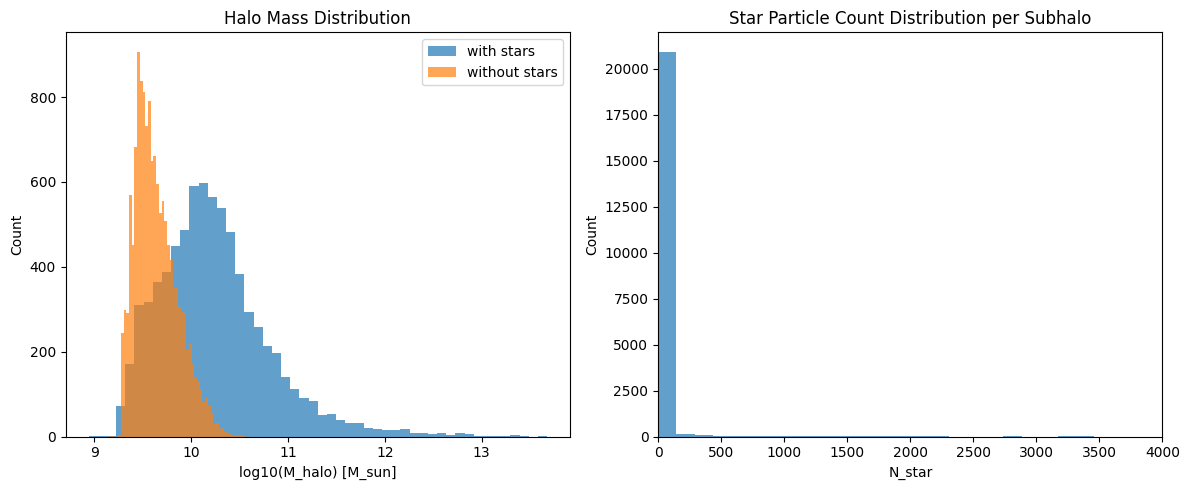

In [5]:
#=== Histograms: Halo Mass Distribution & Star Particle Counts ===#
plt.figure(figsize=(12, 5))

# --- Left panel: Halo mass distribution split by stellar content ---
plt.subplot(1, 2, 1)
plt.hist(np.log10(M_halo_raw[N_star > 0]),  bins=50, alpha=0.7, label="with stars")
plt.hist(np.log10(M_halo_raw[N_star == 0]), bins=50, alpha=0.7, label="without stars")
plt.xlabel("log10(M_halo) [M_sun]")
plt.ylabel("Count")
plt.title("Halo Mass Distribution")
plt.legend()

# --- Right panel: Distribution of star particle counts per subhalo ---
plt.subplot(1, 2, 2)
plt.hist(N_star[N_star >= 0], bins=500, alpha=0.7)
plt.xlabel("N_star")
plt.ylabel("Count")
plt.xlim(0, 4000)
plt.title("Star Particle Count Distribution per Subhalo")

plt.tight_layout()
plt.show()

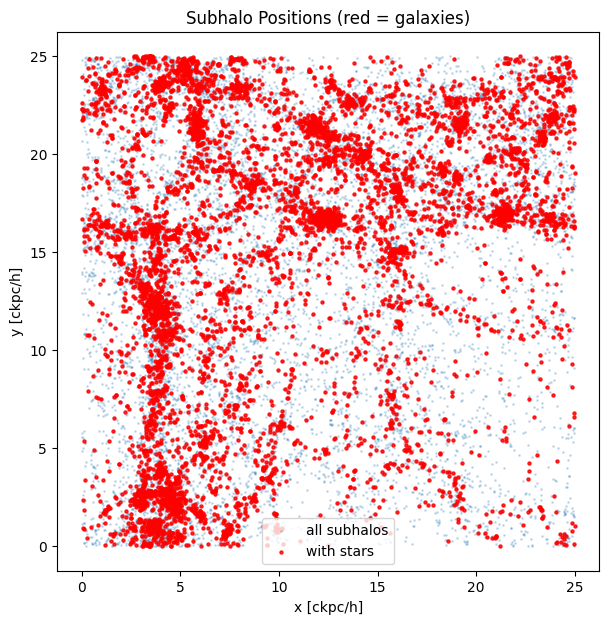

In [6]:
#=== Spatial Distribution of Subhalos ===#
plt.figure(figsize=(7, 7))

# Plot all subhalos in grey, highlight star-hosting ones in red
plt.scatter(pos[:, 0],          pos[:, 1],          s=1, alpha=0.2, label="all subhalos")
plt.scatter(pos[N_star > 0, 0], pos[N_star > 0, 1], s=5, alpha=0.8,
            c="red", label="with stars")

plt.xlabel("x [ckpc/h]")
plt.ylabel("y [ckpc/h]")
plt.title("Subhalo Positions (red = galaxies)")
plt.legend()
plt.show()


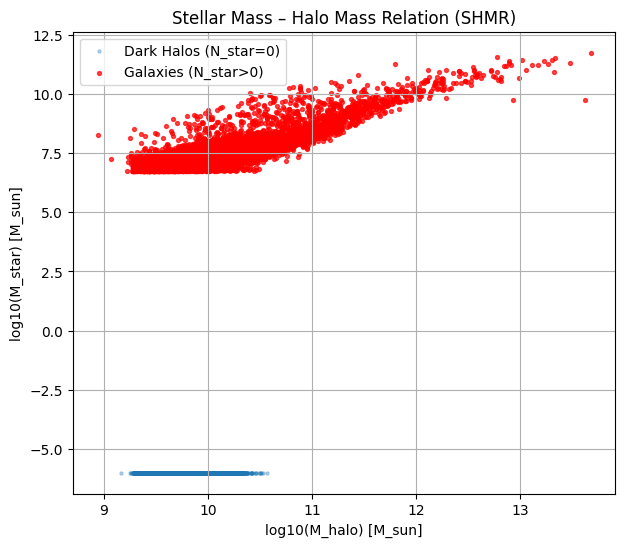

In [7]:
#=== SHRM Raw Scatter ===#
# NOTE: M_star_raw is computed by summing star particle masses per subhalo

# Compute stellar mass per subhalo by summing star particle masses
counts_star, cum_star = build_star_index(snap_files)
N_star_arr   = N_type[:, 4]
Off_star_arr = Off_type[:, 4]
M_star_raw   = np.zeros_like(M_halo_raw, dtype=float)

for i in range(len(M_halo_raw)):
    n = N_star_arr[i]
    if n == 0:
        continue
    off = Off_star_arr[i]
    data = extract_star_particles_global(off, n, snap_files, cum_star,
                                         MASS_UNIT=MASS_UNIT, Z_UNIT=Z_UNIT)
    M_star_raw[i] = data["mass"].sum()

mask_star = (N_star > 0)    # Subhalos with a stellar component
mask_dark = (N_star == 0)   # Pure dark matter halos (no stars)

plt.figure(figsize=(7, 6))

# Dark halos plotted at a fixed low M_star value for visibility
plt.scatter(
    np.log10(M_halo_raw[mask_dark] + 1e-6),
    np.full(np.sum(mask_dark), -6),
    s=5, alpha=0.3, label="Dark Halos (N_star=0)"
)

# Star-hosting subhalos with their actual stellar masses
plt.scatter(
    np.log10(M_halo_raw[mask_star]),
    np.log10(M_star_raw[mask_star]),
    s=8, alpha=0.7, c="red", label="Galaxies (N_star>0)"
)

plt.xlabel("log10(M_halo) [M_sun]")
plt.ylabel("log10(M_star) [M_sun]")
plt.title("Stellar Mass – Halo Mass Relation (SHMR)")
plt.legend()
plt.grid(True)
plt.show()

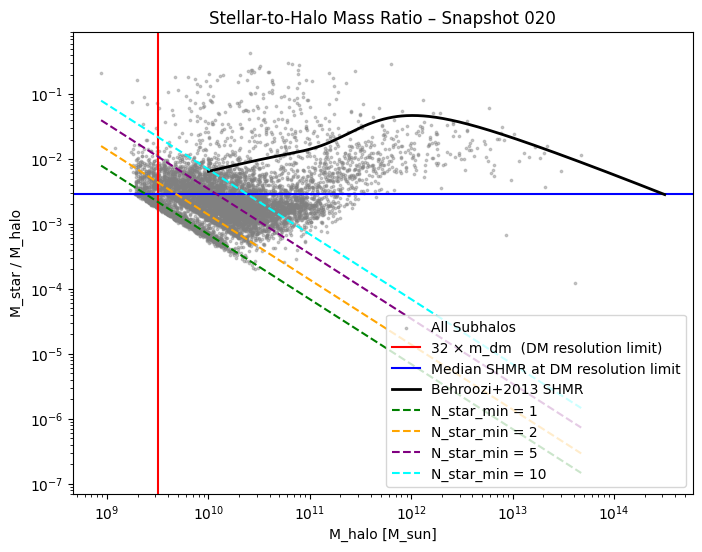

In [ ]:
#=== Behroozi+2013 SHMR Reference Model ===#
def behroozi_shmr_phys(Mhalo_phys):
    """
    Computes the stellar-to-halo mass relation from Behroozi et al. (2013)
    in physical units (z=0 parameters).

    Parameters
    ----------
    Mhalo_phys : array-like
        Halo mass in solar masses [M_sun].

    Returns
    -------
    Mstar_phys : np.ndarray
        Stellar mass in solar masses [M_sun].

    Notes
    -----
    Uses the double power-law parameterisation with characteristic mass M1,
    normalisation epsilon, low-mass slope alpha, and shape parameters delta/gamma.
    """
    # Behroozi+2013 best-fit parameters at z=0
    logM1   = 11.59     # Characteristic halo mass [log10 M_sun]
    epsilon = 0.0351    # Normalisation (M_star/M_halo at M1)
    alpha   = -1.376    # Low-mass slope
    delta   = 3.350     # High-mass deviation amplitude
    gamma   = 0.608     # High-mass deviation shape

    Mh = np.log10(Mhalo_phys)
    x  = Mh - logM1    # Offset from characteristic mass

    def f(x):
        # Shape function: power-law at low mass + log-deviation at high mass
        return (
            -np.log10(10**(alpha * x) + 1)
            + delta * (np.log10(1 + np.exp(x)))**gamma / (1 + np.exp(10**(-x)))
        )

    logMstar_phys = np.log10(epsilon) + logM1 + f(x) - f(0)
    return 10**logMstar_phys



#=== Load Saved Galaxy Files ===#
# NOTE: Requires process_all_snapshots() to have been run beforehand

files = sorted(glob.glob(f"../../DataSave/Galaxies.Storage/snapshot_{snapnum:03d}/*.npy"))

# Collect halo and stellar masses from all saved galaxy files
M_halo_saved = []
M_star_saved = []
m_dm_list    = []
m_star_list  = []

for f in files:
    data = np.load(f, allow_pickle=True).item()
    M_halo_saved.append(data["M_halo"])
    M_star_saved.append(data["M_star"])
    m_dm_list.append(data["m_dm"])
    m_star_list.append(data["m_star"])

M_halo_saved = np.array(M_halo_saved)
M_star_saved = np.array(M_star_saved)

# Use median particle masses as representative values across the snapshot
m_dm   = np.median(m_dm_list)
m_star = np.median(m_star_list)


#=== Resolution Limits & SHMR Ratio Plot ===#
# --- DM resolution limit ---
# A halo is considered resolved if it contains at least 32 DM particles
M_halo_min = 32 * m_dm

# --- Local SHMR at the DM resolution limit ---
# Compute the stellar-to-halo mass ratio for all galaxies
ratio = M_star_saved / M_halo_saved

# Select halos in a narrow mass shell around the DM resolution limit
mask_shell = (M_halo_saved > M_halo_min / 2) & (M_halo_saved < 2 * M_halo_min) & (M_star_saved > 0)
R_local    = np.median(ratio[mask_shell])   # Median SHMR in the resolution shell

# Minimum resolvable stellar mass and corresponding particle count
M_star_min = R_local * M_halo_min
N_star_min = M_star_min / m_star

# --- SHMR Ratio Plot ---
plt.figure(figsize=(8, 6))

# All subhalos as background scatter
plt.scatter(M_halo_saved, ratio, s=3, alpha=0.4, color="gray", label="All Subhalos")

# Vertical line: DM resolution limit (32 particles)
plt.axvline(M_halo_min, color="red",  linestyle="-",
            label="32 × m_dm  (DM resolution limit)")

# Horizontal line: median SHMR at the resolution limit
plt.axhline(R_local, color="blue", linestyle="-",
            label="Median SHMR at DM resolution limit")

# Behroozi+2013 reference curve
Mhalo_grid     = np.logspace(10, 14.5, 400)
Mstar_behroozi = behroozi_shmr_phys(Mhalo_grid)
ratio_behroozi = Mstar_behroozi / Mhalo_grid

plt.plot(Mhalo_grid, ratio_behroozi, color="black", linewidth=2,
         label="Behroozi+2013 SHMR")

# N_star_min iso-lines: show where M_star = N * m_star (stellar resolution limits)
N_values        = [1, 2, 5, 10]
colors          = ["green", "orange", "purple", "cyan"]
Mhalo_grid_full = np.logspace(np.log10(M_halo_saved.min()), np.log10(M_halo_saved.max()), 400)

for N, col in zip(N_values, colors):
    Mstar_min_N = N * m_star                        # Stellar mass for N star particles
    ratio_N     = Mstar_min_N / Mhalo_grid_full     # Corresponding SHMR ratio
    plt.plot(Mhalo_grid_full, ratio_N, linestyle="--", color=col,
             label=f"N_star_min = {N}")

plt.xscale("log")
plt.yscale("log")
plt.xlabel("M_halo [M_sun]")
plt.ylabel("M_star / M_halo")
plt.title(f"Stellar-to-Halo Mass Ratio – Snapshot {snapnum:03d}")
plt.legend(loc="lower right")
plt.show()

# (2) Grid Generation

In [ ]:
#===== Grid Creation =====#
# This snippet will create a FSPS SSP-Grid (ages_gyr x logzsol) and stores it as a .hf/ .HDF5.
# Default parameters include MIST Isochrones, Chabrier IMF, zcontinous = 1
# NOTE: Please refer to the official documentation: https://dfm.io/python-fsps/current/stellarpop_api/#api-reference

#=== Configuration ===#
OUTFILE = "/home/lenna/Synthesizer_Osaka/BigData/FSPS_Grids/fsps_parsec_basel_chabrier.h5"
    # Please rename the Girdname for multiple grids, otherwise they will be overwritten.
#Z_SUN = 0.014           # MISt ~0.014 / Padova ~0.01524
Z_SUN  = 0.01524
ISOCHRONES = "MIST"     # "MIST" or "Padova", or set up others in your environment
IMF_TYPE = 1            # 0: Salpeter,1: Chabrier, 2: Kroupa, 3: van Dokkum, 4: Dave
ZCONTINUOUS = 1         # 1: SSPs are interpolated to the value of logzsol
SFH = 0                 # 0: SSP, 1: 6 paramter SFH, etc. 

# ! Grid Size
N_AGE = 100              # Defines the # of grid points for Age between AGE_MIN_GYR and AGE_MAX_GYR
N_LOGZ = 40              # Defines # of grid points for Metallicity, respectively
# Set Grid boarder
AGE_MIN_GYR = 1e-3
AGE_MAX_GYR = 13.8
LOGZ_MIN = -2
LOGZ_MAX = 0.5

L_SUN_CGS = 3.828e33    # For later conversion [erg/s]

#=== Store Grid ===#
DTYPE_SPEC = "f4"
COMPRESSION = "gzip"
CHUNKS = None           # Will set to (1,1,n_lambda) after the wavelenght is known
# Ensure, output dictionary exists 
os.makedirs(os.path.dirname(OUTFILE), exist_ok=True)

#=== FSPS Object ===#
sp = fsps.StellarPopulation(imf_type=IMF_TYPE,zcontinuous=ZCONTINUOUS,sfh=SFH)
#sp.params["isochrones"] = "MIST"
    
# Safety: Disable unwanted physics
sp.params["add_neb_emission"] = False
sp.params["add_neb_continuum"] = False
sp.params["dust2"] = 0.0
sp.params["dust1"] = 0.0
sp.params["igm_factor"] = 0.0
sp.params["fagn"] = 0.0

#=== Grid ===#
ages_gyr = np.logspace(np.log10(AGE_MIN_GYR), np.log10(AGE_MAX_GYR), N_AGE)
logzsol = np.linspace(LOGZ_MIN, LOGZ_MAX, N_LOGZ)

#=== Grid Creation ===#
with h5py.File(OUTFILE, "w") as f:

    # Speichere Age- und Z-Achsen
    f.create_dataset("ages_gyr", data=ages_gyr)
    f.create_dataset("logzsol", data=logzsol)

    pbar = tqdm(total=N_LOGZ, desc="Building FSPS grid", unit="Z")
    start_time = time.time()

    lam_ds = None
    spec_ds = None

    for j, lz in enumerate(logzsol):

        sp.params["logzsol"] = float(lz)

        # --- Beim ersten Durchlauf: Wellenlängenachse bestimmen ---
        if lam_ds is None:
            wave, _ = sp.get_spectrum(tage=float(ages_gyr[0]), peraa=True)
            lam_ds = f.create_dataset("wavelength", data=wave)
            n_lambda = wave.size

            # Spektren-Dataset anlegen
            spec_ds = f.create_dataset(
                "spectra",
                shape=(N_AGE, N_LOGZ, n_lambda),
                dtype=DTYPE_SPEC,
                compression=COMPRESSION,
                chunks=(1, 1, n_lambda)
            )

        # --- Block für alle Alterswerte ---
        spec_block = np.zeros((N_AGE, n_lambda), dtype=float)

        for i, age in enumerate(ages_gyr):
            wave, spec = sp.get_spectrum(tage=float(age), peraa=True)
            spec_block[i, :] = spec * L_SUN_CGS  # erg/s/Å per Msun

        # --- Block in HDF5 schreiben ---
        spec_ds[:, j, :] = spec_block.astype(DTYPE_SPEC)

        pbar.update(1)

    pbar.close()
    elapsed = time.time() - start_time

   #=== Meta Data ===#
    f.attrs["Z_sun"] = Z_SUN
    f.attrs["imf_type"] = IMF_TYPE
    f.attrs["zcontinuous"] = ZCONTINUOUS
    f.attrs["sfh"] = SFH
    f.attrs["fsps_version"] = fsps.__version__
    f.attrs["units"] = "erg/s/Angstrom per Msun"
    f.attrs["created_on"] = time.strftime("%Y-%m-%dT%H:%M:%SZ", time.gmtime())
    f.attrs["n_age"] = N_AGE
    f.attrs["n_logz"] = N_LOGZ
    f.attrs["build_time_seconds"] = elapsed

print(f"Grid written to {OUTFILE} in {elapsed:.1f} s")

# (3) SED Computing

## 3.1 Cosmological Age and Redshit Conversion

In [10]:
#=== Galaxy File Loader ===#
# Root directory of all saved galaxy .npy files
gal_dir = "/home/lenna/Synthesizer_Osaka/DataSave/Galaxies.Storage"

def load_galaxy(idx, snapnum):
    """
    Loads a single galaxy file by its 6-digit rank index and snapshot number.
    Searches the corresponding snapshot_XXX folder for a file ending in {idx:06d}.npy

    Parameters
    ----------
    idx     : int – galaxy rank index (6-digit)
    snapnum : int – snapshot number

    Returns
    -------
    dict – galaxy data dictionary (loaded via allow_pickle)
    """
    snap_folder   = os.path.join(gal_dir, f"snapshot_{snapnum:03d}")
    target_suffix = f"{idx:06d}.npy"

    if not os.path.isdir(snap_folder):
        raise FileNotFoundError(f"Snapshot folder {snap_folder} does not exist.")

    for fname in os.listdir(snap_folder):
        if fname.endswith(target_suffix):
            path = os.path.join(snap_folder, fname)
            return np.load(path, allow_pickle=True).item()

    raise FileNotFoundError(
        f"No galaxy file with index {idx:06d} found in snapshot_{snapnum:03d}."
    )

#=== Cosmological Age & Redshift Derivation  ===#
# region Cosmological Age & Redshift Conversion
def compute_star_ages(gal, params, header):
    """
    Converts StellarFormationTime (scale factor a_form) to stellar ages in Gyr.
    Age = t(z_snap) - t(z_form), using the simulation cosmology.

    Parameters
    ----------
    gal    : dict   – galaxy data dict, must contain key "age" (= a_form per particle)
    params : attrs  – HDF5 Parameters attributes (HubbleParam, Omega0)
    header : attrs  – HDF5 Header attributes (Time = scale factor of snapshot)

    Returns
    -------
    ages : np.ndarray – stellar ages in Gyr, shape (N_star,)
    """
    h      = params["HubbleParam"]
    H0     = 100 * h                    # Hubble constant [km/s/Mpc]
    Omega0 = params["Omega0"]
    a_snap = header["Time"]             # Scale factor of the snapshot

    cosmo  = FlatLambdaCDM(H0=H0, Om0=Omega0)
    z_snap = 1.0 / a_snap - 1.0        # Redshift of snapshot

    a_form = np.array(gal["age"])       # NOTE: "age" in GADGET stores a_form, not age!
    z_form = 1.0 / a_form - 1.0        # Redshift at stellar formation

    t_form = cosmo.age(z_form)
    t_snap = cosmo.age(z_snap)

    ages = (t_snap - t_form).to(u.Gyr).value
    return ages

def compute_redshifts(gal, header):
    """
    Derives snapshot redshift and per-particle formation redshifts
    from the scale factor, and stores them in the galaxy dictionary.

    Parameters
    ----------
    gal    : dict  – galaxy data dict (modified in-place)
    header : attrs – HDF5 Header attributes (Time = scale factor)

    Returns
    -------
    gal : dict – updated galaxy dict with keys "z_snap" and "z_form"
    """
    a_snap         = header["Time"]
    gal["z_snap"]  = 1.0 / a_snap - 1.0        # Scalar: redshift of snapshot

    a_form         = np.array(gal["age"])        # NOTE: "age" = a_form in GADGET
    gal["z_form"]  = 1.0 / a_form - 1.0         # Array: formation redshift per particle

    return gal

# endregion


## 3.2 SED Derivation

In [11]:
#=== FSPS Grid Class Loader ===#
class FSPSGrid:
    """
    Container for a pre-computed FSPS spectral grid (HDF5 format).

    Expected HDF5 structure:
        ages_gyr    – (N_age,)              stellar ages [Gyr]
        logzsol     – (N_Z,)               log metallicity [log Z/Z_sun]
        wavelength  – (N_lambda,)          wavelength array [Angstrom]
        spectra     – (N_age, N_Z, N_lam)  specific luminosity [L_sun/Angstrom/M_sun]
        attrs/Z_sun – solar metallicity reference value
    """

    def __init__(self, path, imf=None):
        self.grid_path = path
        self.imf       = imf or self._infer_imf_from_filename(path)

        with h5py.File(path, "r") as f:
            self.ages  = f["ages_gyr"][:]        # (N_age,)
            self.logz  = f["logzsol"][:]         # (N_Z,)   log Z/Z_sun
            self.wave  = f["wavelength"][:]      # (N_lambda,)
            self.spec  = f["spectra"][:]         # (N_age, N_Z, N_lambda)
            self.Z_sun = float(f.attrs["Z_sun"]) # Solar metallicity reference

        # Precompute log-age and log-spectra for interpolation
        self.log_ages = np.log10(np.clip(self.ages, 1e-10, None))
        self.log_spec = np.log10(self.spec + 1e-30)  # Offset avoids log(0)

    def _infer_imf_from_filename(self, path):
        """Infers IMF type from filename if not explicitly provided."""
        fname = os.path.basename(path).lower()
        if "chabrier" in fname: return "Chabrier"
        if "kroupa"   in fname: return "Kroupa"
        if "salpeter" in fname: return "Salpeter"
        return "unknown"

#=== Bilinear SED Interpolation (HPC Mode) ===#
def interpolate_sed(grid, ages, Z):
    """
    Bilinear interpolation in log(age) – log(Z/Z_sun) space for N star particles.
    Operates in log-spectral space to preserve dynamic range.

    Parameters
    ----------
    grid : FSPSGrid
    ages : (N,) array – stellar ages [Gyr]
    Z    : (N,) array – absolute metallicity (will be divided by Z_sun internally)

    Returns
    -------
    spectra : (N, N_lambda) array – interpolated SED per particle [L_sun/Ang/M_sun]
    """
    # Convert to log-space and clip to grid bounds
    log_age = np.log10(np.clip(ages, grid.ages.min(), grid.ages.max()))
    logZ    = np.log10(np.clip(Z / grid.Z_sun, 1e-12, None))
    logZ    = np.clip(logZ, grid.logz.min(), grid.logz.max())

    # Find bracketing grid indices for each particle
    i1 = np.searchsorted(grid.log_ages, log_age, side="right")
    i0 = i1 - 1
    j1 = np.searchsorted(grid.logz, logZ, side="right")
    j0 = j1 - 1

    # Clamp to valid index range
    i0 = np.clip(i0, 0, len(grid.ages) - 2)
    i1 = np.clip(i1, 1, len(grid.ages) - 1)
    j0 = np.clip(j0, 0, len(grid.logz) - 2)
    j1 = np.clip(j1, 1, len(grid.logz) - 1)

    # Bilinear interpolation weights
    wi = (log_age - grid.log_ages[i0]) / (grid.log_ages[i1] - grid.log_ages[i0])
    wj = (logZ    - grid.logz[j0])    / (grid.logz[j1]    - grid.logz[j0])

    # Fetch corner spectra in log-space
    S00 = grid.log_spec[i0, j0]   # (N, N_lambda)
    S01 = grid.log_spec[i0, j1]
    S10 = grid.log_spec[i1, j0]
    S11 = grid.log_spec[i1, j1]

    # Reshape weights for broadcasting over wavelength axis
    wi = wi[:, None]
    wj = wj[:, None]

    # Bilinear combination in log-space, then exponentiate
    logS = (
        (1-wi)*(1-wj)*S00 +
        (1-wi)*   wj *S01 +
           wi *(1-wj)*S10 +
           wi *   wj *S11
    )

    return 10**logS

#=== Galaxy SED Computation ===#
# NOTE: It computes the Subbhalo SEDs as a summation of the SEDs of each starparticle,
#       however, it does not store the individual starparticle SEDs.

def compute_galaxy_sed(gal, grid, mode="auto", chunk_size=50000):
    """
    Computes the integrated SED of a galaxy by mass-weighting interpolated
    stellar spectra for all star particles.

    Modes
    -----
    "auto"   : selects mode based on particle count (>200k → laptop)
    "laptop" : memory-efficient; groups particles by grid cell before interpolating
    "hpc"    : full vectorised interpolation; optionally chunked for very large galaxies

    Parameters
    ----------
    gal        : dict    – galaxy dict with keys: stellar_age, Z, mass
    grid       : FSPSGrid
    mode       : str
    chunk_size : int     – chunk size for HPC mode (controls peak RAM usage)

    Returns
    -------
    wavelength : (N_lambda,) array  [Angstrom]
    total_sed  : (N_lambda,) array  [L_sun/Angstrom]
    """
    ages = gal["stellar_age"]
    Z    = gal["Z"]
    mass = gal["mass"]
    N    = len(ages)

    # Auto-select mode based on particle count
    if mode == "auto":
        mode = "laptop" if N > 50_000 else "hpc"


    # NOTE: "Laptop Mode" - group particles by grid cell, interpolate per group
    # Avoids allocating a full (N, N_lambda) array at once

    if mode == "laptop":

        log_age = np.log10(np.clip(ages, grid.ages.min(), grid.ages.max()))
        logZ    = np.log10(np.clip(Z / grid.Z_sun, 1e-12, None))
        logZ    = np.clip(logZ, grid.logz.min(), grid.logz.max())

        # Find bracketing indices
        i1 = np.searchsorted(grid.log_ages, log_age, side="right")
        i0 = i1 - 1
        j1 = np.searchsorted(grid.logz, logZ, side="right")
        j0 = j1 - 1

        i0 = np.clip(i0, 0, len(grid.ages) - 2)
        i1 = np.clip(i1, 1, len(grid.ages) - 1)
        j0 = np.clip(j0, 0, len(grid.logz) - 2)
        j1 = np.clip(j1, 1, len(grid.logz) - 1)

        # Group particles by their (i0, i1, j0, j1) grid cell
        keys              = np.stack([i0, i1, j0, j1], axis=1)
        unique_keys, inverse = np.unique(keys, axis=0, return_inverse=True)

        total_sed = np.zeros_like(grid.wave, dtype=float)

        for k, (ii0, ii1, jj0, jj1) in enumerate(unique_keys):

            mask = (inverse == k)
            m    = mass[mask]

            # Safe denominators
            denom_i = grid.log_ages[ii1] - grid.log_ages[ii0]
            denom_j = grid.logz[jj1]     - grid.logz[jj0]
            if denom_i == 0: denom_i = 1e-12
            if denom_j == 0: denom_j = 1e-12

            wi = (log_age[mask] - grid.log_ages[ii0]) / denom_i
            wj = (logZ[mask]    - grid.logz[jj0])     / denom_j

            wi = wi[:, None]
            wj = wj[:, None]

            # Corner spectra for this grid cell
            S00 = grid.log_spec[ii0, jj0]
            S01 = grid.log_spec[ii0, jj1]
            S10 = grid.log_spec[ii1, jj0]
            S11 = grid.log_spec[ii1, jj1]

            logS = (
                (1-wi)*(1-wj)*S00 +
                (1-wi)*   wj *S01 +
                   wi *(1-wj)*S10 +
                   wi *   wj *S11
            )

            # Mass-weight and accumulate into total SED
            total_sed += np.sum(10**(logS + np.log10(m[:, None])), axis=0)

        return grid.wave, total_sed

    # HPC Mode: full vectorised interpolation, optionally chunked
    if mode == "hpc":

        if N <= chunk_size:
            # All particles fit in memory: single vectorised call
            sed_particles = interpolate_sed(grid, ages, Z)
            total_sed     = np.sum(sed_particles * mass[:, None], axis=0)
            return grid.wave, total_sed

        # Large galaxy: process in chunks to limit peak RAM usage
        total_sed = np.zeros_like(grid.wave, dtype=float)

        for start in range(0, N, chunk_size):
            end         = min(start + chunk_size, N)
            sed_chunk   = interpolate_sed(grid, ages[start:end], Z[start:end])
            total_sed  += np.sum(sed_chunk * mass[start:end, None], axis=0)

        return grid.wave, total_sed

#=== FSPS Grid Loader ===#
def load_fsps_grids(grid_dir):
    """
    Loads all FSPS grid files (*.h5) from a directory into FSPSGrid objects.
    Returns a nested dict: {"FSPS": {grid_name: FSPSGrid, ...}}

    Parameters
    ----------
    grid_dir : str – path to folder containing .h5 grid files

    Returns
    -------
    dict – {"FSPS": {variant_name: FSPSGrid}}
    """
    grids = {}
    for fname in os.listdir(grid_dir):
        if fname.endswith(".h5"):
            key         = fname.replace(".h5", "")
            grids[key]  = FSPSGrid(os.path.join(grid_dir, fname))
    return {"FSPS": grids}


In [12]:
# LEGACY – Single-galaxy updater (superseded by master_compute_seds)

# NOTE: update_galaxy_file_with_fsps_seds() was the original per-galaxy wrapper.
# It is kept here for reference but is fully replaced by master_compute_seds().

def update_galaxy_file_with_fsps_seds(idx, snapnum, gal_dir, grids, params, header):
    """
    Legacy single-galaxy SED updater. Use master_compute_seds() instead.
    """
    snap_folder   = os.path.join(gal_dir, f"snapshot_{snapnum:03d}")
    target_suffix = f"{idx:06d}.npy"
    path          = None

    for fname in os.listdir(snap_folder):
        if fname.endswith(target_suffix):
            path = os.path.join(snap_folder, fname)
            break

    if path is None:
        raise FileNotFoundError(
            f"No galaxy file with index {idx:06d} in snapshot_{snapnum:03d}."
        )

    gal                 = np.load(path, allow_pickle=True).item()
    gal["stellar_age"]  = compute_star_ages(gal, params, header)
    gal                 = compute_redshifts(gal, header)
    gal["sed"]          = {}

    for model_name, variants in grids.items():
        gal["sed"][model_name] = {}
        for variant_name, grid in variants.items():
            lam, sed = compute_galaxy_sed(gal, grid, mode="laptop")
            gal["sed"][model_name][variant_name] = {
                "wavelength": lam,
                "sed":        sed,
                "grid_key":   variant_name,
                "imf":        getattr(grid, "imf", "unknown")
            }

    shutil.copy2(path, path + ".bak")
    np.save(path, gal, allow_pickle=True)
    print(f"Updated (legacy): {os.path.basename(path)}")
    return gal

## *(3.1) MASTER SED Wrapper*

In [6]:
#=== Main SED Pipeline Function ===#
def master_compute_seds(
    gal_root,
    snap_list,
    grids,
    mode="laptop",
    max_galaxies=None,
    galaxy_ids=None         # Optional: list of specific galaxy indices to process
):
    """
    Main pipeline entry point for SED computation across multiple snapshots.

    For each galaxy file:
        1. Compute stellar ages (if missing)
        2. Compute formation redshifts (if missing)
        3. Compute SEDs for all grid variants (skip if already present and valid)
        4. Repair broken SED entries (missing wavelength/sed keys)
        5. Save updated galaxy file in-place

    NOTE: Backup creation is currently disabled (see inline comment).
          Re-enable before running on final data.

    Parameters
    ----------
    gal_root     : str       – root directory of galaxy storage
    snap_list    : list      – list of snapshot numbers to process
    grids        : dict      – nested grid dict {"FSPS": {variant: FSPSGrid}}
    mode         : str       – SED computation mode ("laptop", "hpc", "auto")
    max_galaxies : int       – optional cap on number of galaxies per snapshot (for testing)
    galaxy_ids   : list[int] – optional list of specific galaxy indices to process
                               e.g. [0, 5, 42] → only processes xxxxx_000000.npy etc.
                               If None, all galaxies in the snapshot folder are processed.

    Examples
    --------
    # Run on all galaxies in snapshot 20
    master_compute_seds(gal_root, [20], grids)

    # Run on a single galaxy for testing
    master_compute_seds(gal_root, [20], grids, galaxy_ids=[0])

    # Run on a few specific galaxies
    master_compute_seds(gal_root, [20], grids, galaxy_ids=[0, 5, 42])
    """
    total_count = 0

    for snapnum in snap_list:

        print(f"\n📦 Snapshot {snapnum:03d}")

        # Load cosmological parameters from the first snapshot chunk
        snap_path = f"../../BigData/snapdir_{snapnum:03d}/snapshot_{snapnum:03d}.0.hdf5"
        snap      = h5py.File(snap_path, "r")
        params    = snap["Parameters"].attrs
        header    = snap["Header"].attrs

        snap_folder = os.path.join(gal_root, f"snapshot_{snapnum:03d}")

        if not os.path.isdir(snap_folder):
            print(f"Snapshot folder not found: {snap_folder}")
            continue

        # Collect all galaxy files in the snapshot folder
        files = [f for f in os.listdir(snap_folder) if f.endswith(".npy")]

        # Filter to specific galaxy indices if requested
        if galaxy_ids is not None:
            suffixes = [f"{idx:06d}.npy" for idx in galaxy_ids]
            files    = [f for f in files if any(f.endswith(s) for s in suffixes)]
            print(f"Filtered to {len(files)} specific galaxies (from galaxy_ids)")
        else:
            print(f"Found: {len(files)} galaxies")

        # Optional hard cap on number of galaxies (useful for quick test runs)
        if max_galaxies is not None:
            files = files[:max_galaxies]
            print(f"Capped to {len(files)} galaxies (max_galaxies={max_galaxies})")

        for fname in tqdm(files, desc=f"Snapshot {snapnum:03d}"):

            galaxy_path = os.path.join(snap_folder, fname)

            try:
                gal = np.load(galaxy_path, allow_pickle=True).item()

                # --- Stellar ages (only compute if not already present) ---
                if "stellar_age" not in gal:
                    gal["stellar_age"] = compute_star_ages(gal, params, header)

                # --- Formation redshifts (only compute if not already present) ---
                if "z_snap" not in gal or "z_form" not in gal:
                    gal = compute_redshifts(gal, header)

                # --- Ensure SED container exists ---
                if "sed" not in gal or not isinstance(gal["sed"], dict):
                    gal["sed"] = {}

                # --- Loop over models and grid variants ---
                for model_name, variants in grids.items():

                    if model_name not in gal["sed"] or not isinstance(gal["sed"][model_name], dict):
                        gal["sed"][model_name] = {}

                    for variant_name, grid in variants.items():

                        recompute = False

                        if variant_name in gal["sed"][model_name]:
                            entry = gal["sed"][model_name][variant_name]

                            # Repair broken entries (e.g. from interrupted previous runs)
                            if (
                                not isinstance(entry, dict)
                                or "wavelength" not in entry
                                or "sed" not in entry
                            ):
                                recompute = True
                            else:
                                continue   # Valid entry exists → skip
                        else:
                            recompute = True

                        if recompute:
                            lam, sed = compute_galaxy_sed(gal, grid, mode=mode)
                            gal["sed"][model_name][variant_name] = {
                                "wavelength": lam,
                                "sed":        sed,
                                "grid_key":   variant_name,
                                "imf":        getattr(grid, "imf", "unknown")
                            }

                # NOTE: Backup disabled for performance.
                # Re-enable before running on final/irreplaceable data:
                # backup_path = galaxy_path + ".bak"
                # if not os.path.exists(backup_path):
                #     shutil.copy2(galaxy_path, backup_path)

                np.save(galaxy_path, gal, allow_pickle=True)
                total_count += 1

            except Exception as e:
                print(f"Error processing {fname}: {e}")

    print(f"\nDone. Updated galaxies: {total_count}")

#=== Call Pipeline ===#
# Load all available FSPS grids from directory
grid_dir   = "/home/lenna/Synthesizer_Osaka/BigData/FSPS_Grids/"
fsps_grids = load_fsps_grids(grid_dir)

# Root directory of saved galaxy files
gal_root = "/home/lenna/Synthesizer_Osaka/DataSave/Galaxies.Storage"


In [ ]:
#=== Run MASTER Wrapper ===#
# Run on ALL galaxies
 

# Run on a specific galaxy (debug/test)
#master_compute_seds(
#    gal_root=gal_root,snap_list=[20],grids=fsps_grids,mode="laptop",
#    galaxy_ids=[0])



📦 Snapshot 020
Found: 7456 galaxies


Snapshot 020: 100%|██████████| 7456/7456 [11:28<00:00, 10.83it/s]  


Done. Updated galaxies: 7456


### Debug Test - Compute without saving

In [27]:
#=== Debug Master Function ===#
def test_compute_seds(
    gal_root,
    snap_list,
    grids,
    mode="laptop",
    max_galaxies=10     # Only process a few galaxies for testing
):
    """
    Lightweight test runner for the SED pipeline.
    Does NOT save any results – purely for validation and debugging.

    Checks per galaxy:
        - Stellar age derivation
        - SED computation for all grid variants
        - Basic sanity output (age range, wavelength range, SED sum)

    Parameters
    ----------
    gal_root     : str  – root directory of galaxy storage
    snap_list    : list – list of snapshot numbers to test
    grids        : dict – nested grid dict {"FSPS": {variant: FSPSGrid}}
    mode         : str  – SED computation mode ("laptop", "hpc", "auto")
    max_galaxies : int  – number of galaxies to test per snapshot (default: 10)
    """

    for snapnum in snap_list:
        print(f"\n=== Snapshot {snapnum:03d} ===")

        # Load cosmological parameters from the first snapshot chunk
        snap_path = f"../../BigData/snapdir_{snapnum:03d}/snapshot_{snapnum:03d}.0.hdf5"
        snap      = h5py.File(snap_path, "r")
        params    = snap["Parameters"].attrs
        header    = snap["Header"].attrs

        snap_folder = os.path.join(gal_root, f"snapshot_{snapnum:03d}")

        if not os.path.isdir(snap_folder):
            print(f"Snapshot folder not found: {snap_folder}")
            continue

        files = [f for f in os.listdir(snap_folder) if f.endswith(".npy")]
        print(f"Found: {len(files)} galaxies – testing first {max_galaxies}")
        files = files[:max_galaxies]

        for fname in files:
            path = os.path.join(snap_folder, fname)
            print(f"\n→ Testing: {fname}")

            gal  = np.load(path, allow_pickle=True).item()
            ages = compute_star_ages(gal, params, header)
            print(f"   Ages:      min={ages.min():.3f}, max={ages.max():.3f} Gyr")

            # Test SED computation for all grid variants
            for model_name, variants in grids.items():
                for variant_name, grid in variants.items():

                    lam, sed = compute_galaxy_sed(
                        {**gal, "stellar_age": ages},
                        grid,
                        mode=mode
                    )

                    print(f"   Grid:      {variant_name}  (IMF: {grid.imf})")
                    print(f"   λ range:   {lam.min():.1f} – {lam.max():.1f} Å")
                    print(f"   SED sum:   {np.sum(sed):.3e} L_sun/Å")

                    # Basic sanity checks
                    if np.any(np.isnan(sed)):
                        print(f"   ⚠️  WARNING: NaN values detected in SED!")
                    if np.any(sed < 0):
                        print(f"   ⚠️  WARNING: Negative values detected in SED!")

        print(f"\n--- Snapshot {snapnum:03d} done ---")

In [ ]:
test_compute_seds(
    gal_root=gal_root,
    snap_list=[20],
    grids=fsps_grids,
    mode="laptop",
    max_galaxies=10
)

## (3.x) AnA

In [13]:
#=== PLOT SETUP – Load dependencies ===#
# NOTE: Requires the following to have been run/defined beforehand:
#   - FSPSGrid         (Section 3 – SED Computing)
#   - load_galaxy_by_idx / load_galaxy  (Section 1 – SED Computing)
#   - load_fsps_grids  (Section 6 – SED Computing)

#=== Load Galaxy ===#
def load_galaxy_by_idx(gal_root, snapnum, idx):
    snap_folder = os.path.join(gal_root, f"snapshot_{snapnum:03d}")
    target = f"{idx:06d}.npy"

    for fname in os.listdir(snap_folder):
        if fname.endswith(target):
            path = os.path.join(snap_folder, fname)
            return np.load(path, allow_pickle=True).item()

    raise FileNotFoundError(f"Galaxy {idx:06d} nicht gefunden in snapshot {snapnum}")

# Root directory of saved galaxy files
gal_root = "/home/lenna/Synthesizer_Osaka/DataSave/Galaxies.Storage"

# Load all available FSPS grids
fsps_grids = load_fsps_grids("/home/lenna/Synthesizer_Osaka/BigData/FSPS_Grids/")
fsps_grids

gal     = load_galaxy_by_idx(gal_root, snapnum=20, idx=0)

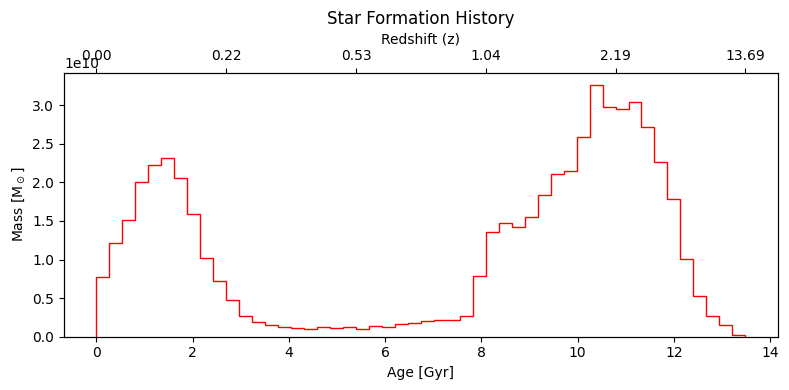

In [14]:
#===== Stellar Formation Histrogram =====#
fig, ax = plt.subplots(figsize=(8, 4))

ax.hist(gal["stellar_age"], bins=50, weights=gal["mass"],
        color="black", edgecolor="red", histtype="step")

ax.set_xlabel("Age [Gyr]")
ax.set_ylabel("Mass [M$_\\odot$]")
ax.set_title("Star Formation History")

# --- Zweite x-Achse oben: Redshift ---
ax2 = ax.twiny()

# Achsenlimits synchronisieren
ax2.set_xlim(ax.get_xlim())

# Tick-Positionen in t_form
t_ticks = np.linspace(gal["stellar_age"].min(), gal["stellar_age"].max(), 6)

# Umrechnung t -> z (du hast z_form bereits!)
# Wir nehmen den Mittelwert pro t-Tick:
z_ticks = []

for t in t_ticks:
    # nächster Sternpartikel in der Nähe dieses t
    idx = np.argmin(np.abs(gal["stellar_age"] - t))
    z_ticks.append(gal["z_form"][idx])

ax2.set_xticks(t_ticks)
ax2.set_xticklabels([f"{z:.2f}" for z in z_ticks])
ax2.set_xlabel("Redshift (z)")

plt.tight_layout()
plt.show()


### Single Grid

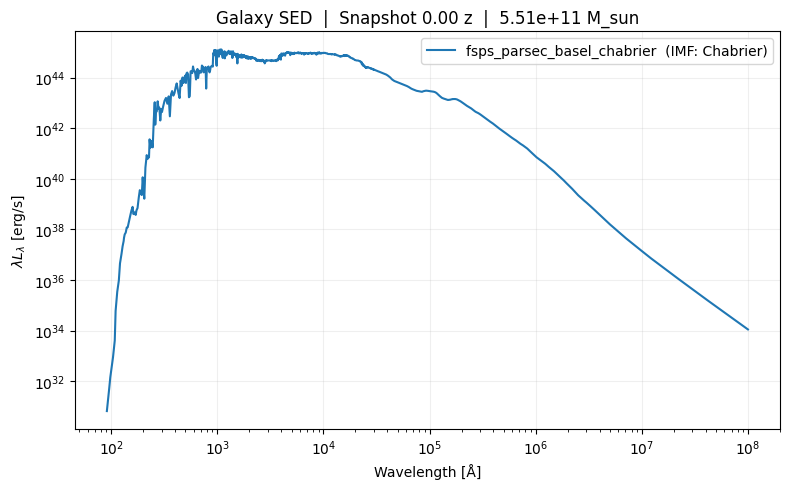

In [15]:
#=== Single Grid Plot ===#
def plot_galaxy_sed(gal, model="FSPS", variant=None, show_lambda_L_lambda=True):
    """
    Plots the integrated SED of a single galaxy.

    Parameters
    ----------
    gal                  : dict – galaxy data dict (must contain "sed" key)
    model                : str  – model name to plot, e.g. "FSPS"
    variant              : str  – grid variant name (IMF), e.g. "chabrier"
                                  If None, the first available variant is used
    show_lambda_L_lambda : bool – if True,  plot λ·L_λ  [erg/s]
                                  if False, plot   L_λ  [erg/s/Å]
    """
    if "sed" not in gal:
        raise ValueError("No SED found in galaxy dict. Run master_compute_seds() first.")

    if model not in gal["sed"]:
        raise ValueError(f"Model '{model}' not found. Available: {list(gal['sed'].keys())}")

    sed_data = gal["sed"][model]

    # Use first available variant if none specified
    if variant is None:
        variant = list(sed_data.keys())[0]

    if variant not in sed_data:
        raise ValueError(f"Variant '{variant}' not found. Available: {list(sed_data.keys())}")

    entry = sed_data[variant]
    lam   = entry["wavelength"]
    sed   = entry["sed"]

    # Select y-axis quantity
    if show_lambda_L_lambda:
        y      = lam * sed
        ylabel = r"$\lambda L_\lambda$ [erg/s]"
    else:
        y      = sed
        ylabel = r"$L_\lambda$ [erg/s/Å]"

    # Safe title formatting: handle missing z_snap and M_star
    z_snap = gal.get("z_snap", None)
    M_star = gal.get("M_star", None)
    z_str  = f"{z_snap:.2f} z"      if z_snap is not None else "z unknown"
    M_str  = f"{M_star:.2e} M_sun"  if M_star is not None else "M_star unknown"

    # --- Plot ---
    plt.figure(figsize=(8, 5))
    plt.loglog(lam, y, label=f"{variant}  (IMF: {entry.get('imf', 'unknown')})")

    plt.xlabel("Wavelength [Å]")
    plt.ylabel(ylabel)
    plt.title(f"Galaxy SED  |  Snapshot {z_str}  |  {M_str}")
    plt.grid(alpha=0.2)
    plt.legend()
    plt.tight_layout()
    plt.show()

gal = load_galaxy_by_idx(gal_root, snapnum=20, idx=0)

# Default: first available variant, λL_λ
plot_galaxy_sed(gal)

# Specific variant, L_λ
# plot_galaxy_sed(gal, variant="chabrier", show_lambda_L_lambda=False)

### Grid Pairs

In [23]:
#=== Grid Pairs ===#
def plot_sed_pairs(gal, pairs, show_lambda_L_lambda=True, normalize=False):
    """
    Plots multiple SED variants of a single galaxy for direct comparison.
    Each pair (model, variant) is plotted as a separate line.

    Parameters
    ----------
    gal                  : dict          – galaxy data dict (must contain "sed" key)
    pairs                : list of tuple – list of (model, variant) to plot
                                           e.g. [("FSPS", "chabrier"), ("FSPS", "kroupa")]
    show_lambda_L_lambda : bool          – if True,  plot λ·L_λ  [erg/s]
                                           if False, plot   L_λ  [erg/s/Å]
    normalize            : bool          – if True, normalise each SED to its peak value
                                           useful for shape comparison across IMFs
    """
    if "sed" not in gal:
        raise ValueError("No SED found in galaxy dict. Run master_compute_seds() first.")

    # Safe title formatting
    z_snap = gal.get("z_snap", None)
    M_star = gal.get("M_star", None)
    z_str  = f"{z_snap:.2f} z"     if z_snap is not None else "z unknown"
    M_str  = f"{M_star:.2e} M_sun" if M_star is not None else "M_star unknown"

    plt.figure(figsize=(8, 5))

    for model, variant in pairs:
        try:
            entry = gal["sed"][model][variant]
        except KeyError:
            print(f"Warning: {model} / {variant} not found – skipping.")
            continue

        lam = entry["wavelength"]
        sed = entry["sed"]

        # Select y-axis quantity
        if show_lambda_L_lambda:
            y      = lam * sed
            ylabel = r"$\lambda L_\lambda$ [erg/s]"
        else:
            y      = sed
            ylabel = r"$L_\lambda$ [erg/s/Å]"

        # Optional peak normalisation for shape comparison
        if normalize:
            y      = y / np.max(y)
            ylabel = "Normalised " + ylabel

        plt.loglog(lam, y, label=f"{model} | {variant}  (IMF: {entry.get('imf', 'unknown')})")

    plt.xlabel("Wavelength [Å]")
    plt.ylabel(ylabel)
    plt.ylim(1e40, 1e46)
    plt.xlim(1e2,  1e6)
    plt.title(f"Spectral Energy Distribution")
    plt.grid(True, which="both", alpha=0.2)
    plt.legend()
    plt.tight_layout()
    plt.show()
def plot_all_seds(gal, model=None):
    """
    Convenience wrapper: plots all available SED variants stored in a galaxy dict.
    Collects all (model, variant) pairs and passes them to plot_sed_pairs().

    Parameters
    ----------
    gal   : dict – galaxy data dict (must contain "sed" key)
    model : str  – if provided, only plot variants of this model (e.g. "FSPS")
                   if None, plot all models and variants
    """
    if "sed" not in gal:
        raise ValueError("No SED found in galaxy dict. Run master_compute_seds() first.")

    pairs = [
        (m, variant)
        for m, variants in gal["sed"].items()
        for variant in variants.keys()
        if model is None or m == model   # Filter by model if specified
    ]

    if not pairs:
        print(f"Warning: No SED variants found{f' for model {model}' if model else ''} – nothing to plot.")
        return

    plot_sed_pairs(gal, pairs)
def plot_sed_for_subhalo(
        snapnum,
        idx,
        pairs,
        show_lambda_L_lambda=True,  # NEW: durchreichen an plot_sed_pairs
        normalize=False,             # NEW: durchreichen an plot_sed_pairs
        base_dir="/home/lenna/Synthesizer_Osaka/DataSave/Galaxies.Storage"
    ):
    """
    Convenience wrapper: loads a galaxy file by snapshot number and rank index,
    then plots the requested SED pairs via plot_sed_pairs().

    Parameters
    ----------
    snapnum              : int          – snapshot number
    idx                  : int          – galaxy rank index (6-digit)
    pairs                : list of tuple – list of (model, variant) to plot
                                           e.g. [("FSPS", "chabrier")]
    show_lambda_L_lambda : bool         – passed to plot_sed_pairs()
    normalize            : bool         – passed to plot_sed_pairs()
    base_dir             : str          – root directory of galaxy storage
    """
    snap_dir = os.path.join(base_dir, f"snapshot_{snapnum:03d}")
    pattern  = f"_{snapnum:03d}.{idx:06d}.npy"

    matches = [f for f in os.listdir(snap_dir) if f.endswith(pattern)]

    if len(matches) == 0:
        raise FileNotFoundError(f"No file found for snap={snapnum}, idx={idx}")
    if len(matches) > 1:
        print("Warning: Multiple files found – using the first match.")

    fname = matches[0]
    gal   = np.load(os.path.join(snap_dir, fname), allow_pickle=True).item()

    print(f"Loaded:     {fname}")
    print(f"Subhalo-ID: {gal['subhalo_id']}  |  FoF-ID: {gal['fof_id']}")
    print(f"M_star:     {gal.get('M_star', 'unknown'):.2e} M_sun")

    plot_sed_pairs(gal, pairs,
                   show_lambda_L_lambda=show_lambda_L_lambda,
                   normalize=normalize)

Loaded:     Galaxy0072072_020.000000.npy
Subhalo-ID: 0  |  FoF-ID: 0
M_star:     5.51e+11 M_sun


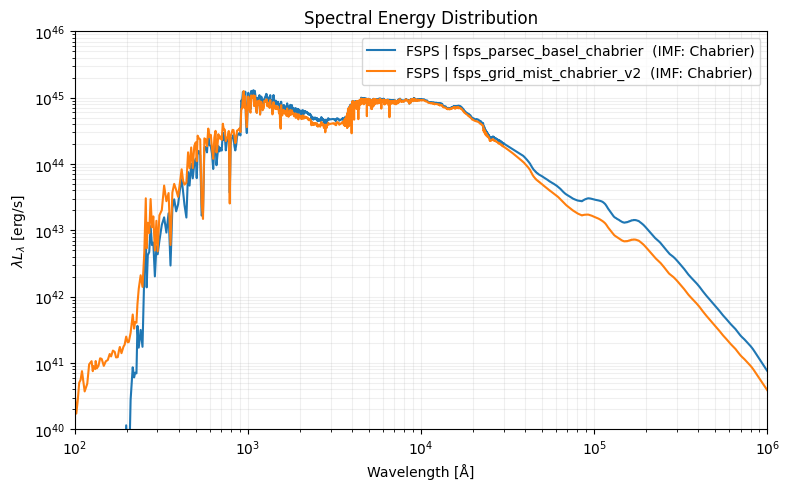

In [24]:
# Already loaded gal Dict → plot_sed_pairs / plot_all_seds
#plot_all_seds(gal)
#plot_sed_pairs(gal, [("FSPS", "fsps_parsec_basel_chabrier"), ("FSPS", "fsps_grid_mist_chabrier_v2")])
#plot_all_seds(gal, model="FSPS")

# Plot directly via Index
plot_sed_for_subhalo(snapnum=20, idx=0, pairs=[("FSPS", "fsps_parsec_basel_chabrier"), ("FSPS", "fsps_grid_mist_chabrier_v2")])

# With Options
#plot_sed_for_subhalo(snapnum=20, idx=0, pairs=[("FSPS", "fsps_parsec_basel_chabrier")],
#                     normalize=False, show_lambda_L_lambda=True)

# (4) Filter Application

## (4.x) Test Filters

Filter Bereich: 3630.0 - 5830.0 Å
SED Bereich: 91.0 - 100000000.0 Å
Filter Wellenlängen: (1963,)
SED Wellenlängen:    (1963,)
SED Bereich: 91.0 - 100000000.0 Å
g-Filter Bereich: 3630.0 - 5830.0 Å
r-Filter Bereich: 5380.0 - 7230.0 Å


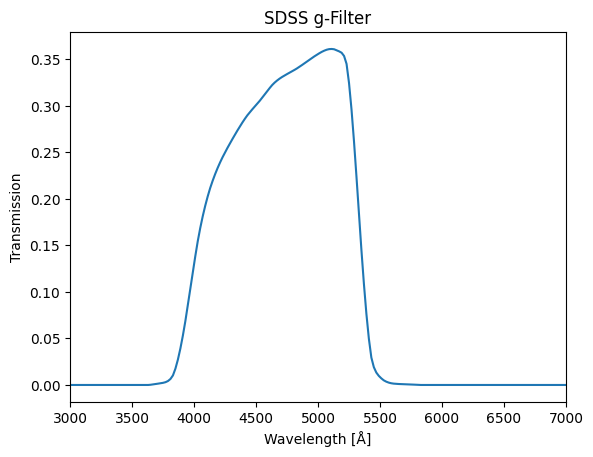

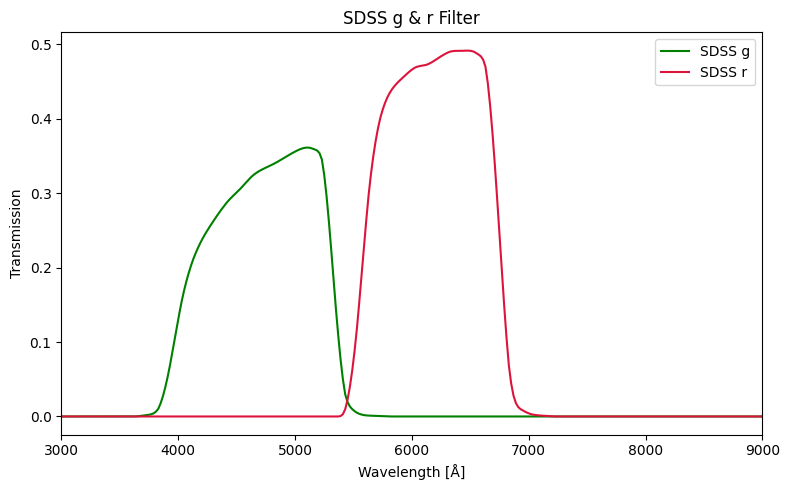

Interpolierte g-Filter: (1963,)
Interpolierte r-Filter: (1963,)


In [57]:
#=== Filter Check ===#
f = fsps.get_filter('sdss_g')
wave_filter = f.transmission[0]
trans_filter = f.transmission[1]

# Dein SED Wellenlängengrid
wave_sed = fsps_grids["FSPS"]["fsps_parsec_basel_chabrier"].wave

print("Filter Bereich:", wave_filter.min(), "-", wave_filter.max(), "Å")
print("SED Bereich:", wave_sed.min(), "-", wave_sed.max(), "Å")

# Filter auf SED Wellenlängengrid interpolieren
trans_interp = np.interp(
    wave_sed,          # Neues Grid (dein SED Grid)
    wave_filter,       # Altes Grid (Filter Grid)
    trans_filter,      # Transmission
    left=0.0,          # Außerhalb des Filters = 0
    right=0.0
)

plt.plot(wave_sed, trans_interp)
plt.xlim(3000, 7000)
plt.xlabel("Wavelength [Å]")
plt.ylabel("Transmission")
plt.title("SDSS g-Filter")

print("Filter Wellenlängen:", trans_interp.shape)
print("SED Wellenlängen:   ", wave_sed.shape)
# Erzwingt die vollständige Ausgabe des Arrays
#with np.printoptions(threshold=np.inf):
#    print(trans_interp)

#=== Filter Check: SDSS g + SDSS r ===#

# --- SDSS g ---
f_g = fsps.get_filter('sdss_g')
wave_g = f_g.transmission[0]
trans_g = f_g.transmission[1]

# --- SDSS r ---
f_r = fsps.get_filter('sdss_r')
wave_r = f_r.transmission[0]
trans_r = f_r.transmission[1]

# --- Dein SED Grid ---
wave_sed = fsps_grids["FSPS"]["fsps_parsec_basel_chabrier"].wave

print("SED Bereich:", wave_sed.min(), "-", wave_sed.max(), "Å")
print("g-Filter Bereich:", wave_g.min(), "-", wave_g.max(), "Å")
print("r-Filter Bereich:", wave_r.min(), "-", wave_r.max(), "Å")

# --- Interpolation auf SED Grid ---
trans_g_interp = np.interp(wave_sed, wave_g, trans_g, left=0.0, right=0.0)
trans_r_interp = np.interp(wave_sed, wave_r, trans_r, left=0.0, right=0.0)

# --- Plot ---
plt.figure(figsize=(8,5))

plt.plot(wave_sed, trans_g_interp, label="SDSS g", color="green")
plt.plot(wave_sed, trans_r_interp, label="SDSS r", color="crimson")

plt.xlim(3000, 9000)
plt.xlabel("Wavelength [Å]")
plt.ylabel("Transmission")
plt.title("SDSS g & r Filter")
plt.legend()

plt.tight_layout()
plt.show()

print("Interpolierte g-Filter:", trans_g_interp.shape)
print("Interpolierte r-Filter:", trans_r_interp.shape)

## (4.1) Main Filter Application

In [ ]:
#===== Filter Application =====#
# NOTE: Requires the following to have been run/defined beforehand:
#   - FSPSGrid         (Section 3 – SED Computing)
#   - (load_galaxy_by_idx) / load_galaxy  (Section 1 – SED Computing)
#   - load_fsps_grids  (Section 6 – SED Computing)

#=== Constants ===#
C_LIGHT = 2.998e18    # Speed of light [Å/s]
D_10PC  = 3.0857e19   # 10 pc in cm – used for absolute magnitude computation
SDSS_FILTERS = ['sdss_u', 'sdss_g', 'sdss_r', 'sdss_i', 'sdss_z']   # Change if necessary

# NOTE: fsps.list_filters() - Lists all available filters in FSPS

#=== Filter Loader ===#
def load_sdss_filters(wave_sed):
    """
    Loads all SDSS filters and interpolates their transmission curves
    onto the SED wavelength grid.

    Parameters
    ----------
    wave_sed : (N_lambda,) array – SED wavelength grid [Å]

    Returns
    -------
    dict : {filter_name: {"trans_interp": array, "lambda_eff": float}}
    """
    filters = {}

    for fname in SDSS_FILTERS:
        f            = fsps.get_filter(fname)
        wave_filter  = f.transmission[0]
        trans_filter = f.transmission[1]

        # Interpolate filter transmission onto SED wavelength grid
        # Zero outside filter bounds
        trans_interp = np.interp(wave_sed, wave_filter, trans_filter,
                                 left=0.0, right=0.0)

        # Effective wavelength: transmission-weighted mean wavelength
        mask       = trans_interp > 0
        lambda_eff = np.average(wave_sed[mask], weights=trans_interp[mask])

        filters[fname] = {
            "trans_interp": trans_interp,
            "lambda_eff"  : lambda_eff
        }

    return filters

#=== Calculate Magnitude ===#
def compute_magnitude(sed_lambda, mass, wave, trans):
    """
    Computes the absolute AB magnitude for a single star particle
    using proper bandpass integration.

    Steps
    -----
    1. Scale SSP SED by stellar particle mass
    2. Convert L_lambda -> L_nu
    3. Integrate band-averaged L_nu over the filter response
    4. Convert luminosity to flux at 10 pc
    5. Compute AB magnitude

    Parameters
    ----------
    sed_lambda : (N_lambda,) array
     Spectral luminosity density [erg/s/Å per M_sun]

    mass : float
        Stellar particle mass [M_sun]

    wave : (N_lambda,) array
        Wavelength grid [Å]

    trans : (N_lambda,) array
        Filter transmission curve interpolated onto the SED grid

    Returns
    -------
    float
        Absolute AB magnitude
    """
    # Spectral luminosity density
    L_lambda = sed_lambda * mass   # erg/s/Å

    # Convert to L_nu
    L_nu = L_lambda * wave**2 / C_LIGHT

    # Integrate in ln(lambda)
    lnwave = np.log(wave)

    numerator = np.trapezoid(
        L_nu * trans,
        x=lnwave
    )

    denominator = np.trapezoid(
        trans,
        x=lnwave
    )

    Lnu_mean = numerator / denominator

    # Flux at 10 pc
    Fnu_10pc = Lnu_mean / (4 * np.pi * D_10PC**2)

    if Fnu_10pc <= 0:
        return np.nan

    return -2.5 * np.log10(Fnu_10pc) - 48.6

#=== Per-Galaxy Photometry ===#
def compute_galaxy_photometry(gal, grids, chunk_size=10000, overwrite=False):
    """
    Computes per-particle SDSS photometry for all grid variants of a galaxy.
    Uses chunking to limit peak RAM usage.

    Skips variants where photometry already exists (safe to re-run).
    Skips variants where no SED has been computed yet.

    Parameters
    ----------
    gal        : dict – galaxy data dict (must contain "stellar_age", "Z", "mass", "sed")
    grids      : dict – nested grid dict {"FSPS": {variant: FSPSGrid}}
    chunk_size : int  – number of particles per chunk (RAM control)

    Returns
    -------
    gal : dict – updated galaxy dict with photometry stored under
                 gal["sed"][model][variant]["photometry"]
    """
    ages = gal["stellar_age"]
    Z    = gal["Z"]
    mass = gal["mass"]
    N    = len(ages)

    for model_name, variants in grids.items():
        for variant_name, grid in variants.items():

            # Skip if no SED has been computed for this variant
            if (
                "sed" not in gal
                or model_name not in gal["sed"]
                or variant_name not in gal["sed"][model_name]
            ):
                print(f"Warning: No SED found for {model_name}/{variant_name} – skipping.")
                continue

            if (
                "photometry"
                in gal["sed"][model_name][variant_name]
                and not overwrite
            ):
                continue

            # Load filters interpolated onto this grid's wavelength axis
            wave_sed = grid.wave
            filters  = load_sdss_filters(wave_sed)

            # Initialise magnitude arrays for all particles
            mags = {fname: np.zeros(N) for fname in SDSS_FILTERS}

            # Chunked computation to limit peak RAM
            for start in range(0, N, chunk_size):
                end = min(start + chunk_size, N)

                # Interpolate SEDs for this chunk only: (chunk_size, N_lambda)
                sed_chunk = interpolate_sed(grid, ages[start:end], Z[start:end])

                for i in range(end - start):
                    for fname, fdata in filters.items():
                        mags[fname][start + i] = compute_magnitude(
                            sed_lambda   = sed_chunk[i],
                            mass         = mass[start + i],
                            trans        = fdata["trans_interp"],
                            #lambda_eff   = fdata["lambda_eff"],
                            wave         = wave_sed
                        )

            # Store photometry under the corresponding SED variant
            gal["sed"][model_name][variant_name]["photometry"] = {
                "M_u": mags["sdss_u"],
                "M_g": mags["sdss_g"],
                "M_r": mags["sdss_r"],
                "M_i": mags["sdss_i"],
                "M_z": mags["sdss_z"],
            }

            gal["sed"][model_name][variant_name]["photometry_meta"] = {

                "system"      : "AB",
                "filters"     : SDSS_FILTERS,
                "integration" : "bandpass_lnlambda_trapezoid",
                "flux_type"   : "L_nu",
                "units_input" : "erg/s/Å/Msun",
                "distance"    : "10pc",
                "overwrite"   : overwrite
            }

    return gal


In [23]:
gal

{'mass': array([ 7670909.07845832,  6324735.55004749, 12929578.82017292, ...,
         5594259.99506605,  7798670.0050017 ,  5695466.07149133],
       shape=(72072,)),
 'pos': array([[4.6158323 , 2.2318933 , 0.95149004],
        [4.615661  , 2.2319882 , 0.95168716],
        [4.6156607 , 2.2319686 , 0.9519043 ],
        ...,
        [4.519239  , 2.214795  , 0.8267772 ],
        [4.6268888 , 2.1453166 , 1.0398262 ],
        [4.216815  , 2.6153429 , 0.5792334 ]],
       shape=(72072, 3), dtype=float32),
 'age': array([0.9136251 , 0.89084303, 0.9301651 , ..., 0.2541525 , 0.7813676 ,
        0.454126  ], shape=(72072,), dtype=float32),
 'Z': array([2.3969341e-02, 7.1781022e-03, 1.9890703e-02, ..., 1.3862714e-05,
        2.1013450e-02, 4.7507583e-05], shape=(72072,), dtype=float32),
 'fof_id': np.int64(0),
 'subhalo_id': np.int64(0),
 'M_halo': np.float64(47426091365032.03),
 'M_star': np.float64(550985224857.4615),
 'm_dm': np.float64(99731288.72998425),
 'm_star': np.float64(6928121.041927

### Legacy

In [38]:
#===== Different Magnitude Derivations =====#
# If you want to use a different derivation, delete the "... v1" and replace it in the actual function above.
#=== Flux Approximation ===#
# Here, the flux is approximated: F_nu = F_lmabda * \lambda**2 / c
def compute_magnitudev1(sed, mass, trans_interp, lambda_eff, wave_sed):
    """
    Computes the absolute AB magnitude for a single star particle.

    Steps:
        1. Convolve SED with filter transmission curve
        2. Convert F_lambda → L_nu → F_nu at 10 pc
        3. Compute AB magnitude

    Parameters
    ----------
    sed          : (N_lambda,) array – specific luminosity [erg/s/Å per M_sun]
    mass         : float             – stellar mass [M_sun]
    trans_interp : (N_lambda,) array – filter transmission on SED grid
    lambda_eff   : float             – effective filter wavelength [Å]
    wave_sed     : (N_lambda,) array – wavelength grid [Å]

    Returns
    -------
    float : Absolute AB magnitude
    """
    # Convolve SED with filter: flux-weighted mean over filter bandpass
    numerator   = np.trapezoid(sed * trans_interp, wave_sed)
    denominator = np.trapezoid(trans_interp, wave_sed)
    f_mean      = numerator / denominator

    # Scale by particle mass and convert F_lambda → L_nu → F_nu at 10 pc
    f_lambda = f_mean * mass
    L_nu     = f_lambda * lambda_eff**2 / C_LIGHT
    F_nu     = L_nu / (4 * np.pi * D_10PC**2)

    # AB magnitude definition: m_AB = -2.5 log10(F_nu) - 48.6
    return -2.5 * np.log10(F_nu) - 48.6

#=== AB-Magnites by Riemann-Sum ===#
def compute_magnitudev1(sed_lambda, mass, wave, trans):

    # Total spectral luminosity density
    L_lambda = sed_lambda * mass   # erg/s/Å

    # Convert L_lambda -> L_nu
    L_nu = L_lambda * wave**2 / C_LIGHT

    # d ln lambda
    dln_lambda = np.gradient(np.log(wave))

    # Band-averaged L_nu
    numerator   = np.sum(L_nu * trans * dln_lambda)
    denominator = np.sum(trans * dln_lambda)

    Lnu_mean = numerator / denominator

    # Flux at 10 pc
    Fnu_10pc = Lnu_mean / (4 * np.pi * D_10PC**2)

    # Safety
    if Fnu_10pc <= 0:
        return np.nan

    return -2.5 * np.log10(Fnu_10pc) - 48.6

#=== AB-Magnitudes by real Integration ===#
def compute_magnitudev1(sed_lambda, mass, wave, trans):

    # Spectral luminosity density
    L_lambda = sed_lambda * mass   # erg/s/Å

    # Convert to L_nu
    L_nu = L_lambda * wave**2 / C_LIGHT

    # Integrate in ln(lambda)
    lnwave = np.log(wave)

    numerator = np.trapezoid(
        L_nu * trans,
        x=lnwave
    )

    denominator = np.trapezoid(
        trans,
        x=lnwave
    )

    Lnu_mean = numerator / denominator

    # Flux at 10 pc
    Fnu_10pc = Lnu_mean / (4 * np.pi * D_10PC**2)

    if Fnu_10pc <= 0:
        return np.nan

    return -2.5 * np.log10(Fnu_10pc) - 48.6

## *(3.1) MASTER Wrapper Photometry*

In [36]:
#=== Main Filter Function ===#
def master_compute_photometry(
    gal_root,
    snap_list,
    grids,
    max_galaxies=None,
    galaxy_ids=None     # Optional: list of specific galaxy indices to process
):
    """
    Main pipeline entry point for photometry computation across multiple snapshots.

    For each galaxy file:
        1. Load galaxy dict
        2. Compute SDSS photometry for all grid variants (skip if already present)
        3. Save updated galaxy file in-place

    Parameters
    ----------
    gal_root     : str       – root directory of galaxy storage
    snap_list    : list      – list of snapshot numbers to process
    grids        : dict      – nested grid dict {"FSPS": {variant: FSPSGrid}}
    max_galaxies : int       – optional cap on number of galaxies per snapshot
    galaxy_ids   : list[int] – optional list of specific galaxy indices to process
                               If None, all galaxies are processed
    """
    total_count = 0

    for snapnum in snap_list:

        print(f"\n📦 Snapshot {snapnum:03d}")

        snap_folder = os.path.join(gal_root, f"snapshot_{snapnum:03d}")

        if not os.path.isdir(snap_folder):
            print(f"Snapshot folder not found: {snap_folder}")
            continue

        files = [f for f in os.listdir(snap_folder) if f.endswith(".npy")]

        # Filter to specific galaxy indices if requested
        if galaxy_ids is not None:
            suffixes = [f"{idx:06d}.npy" for idx in galaxy_ids]
            files    = [f for f in files if any(f.endswith(s) for s in suffixes)]
            print(f"Filtered to {len(files)} specific galaxies (from galaxy_ids)")
        else:
            print(f"Found: {len(files)} galaxies")

        if max_galaxies is not None:
            files = files[:max_galaxies]
            print(f"Capped to {len(files)} galaxies (max_galaxies={max_galaxies})")

        for fname in tqdm(files, desc=f"Snapshot {snapnum:03d}"):

            galaxy_path = os.path.join(snap_folder, fname)

            try:
                gal = np.load(galaxy_path, allow_pickle=True).item()
                gal = compute_galaxy_photometry(gal, grids, overwrite=True)
                np.save(galaxy_path, gal, allow_pickle=True)
                total_count += 1

            except Exception as e:
                print(f"Error processing {fname}: {e}")

    print(f"\nDone. Updated galaxies: {total_count}")

gal_root   = "/home/lenna/Synthesizer_Osaka/DataSave/Galaxies.Storage"
grid_dir   = "/home/lenna/Synthesizer_Osaka/BigData/FSPS_Grids/"
fsps_grids = load_fsps_grids(grid_dir)

In [37]:
#=== Run Master Wrapper ===#
master_compute_photometry(
    gal_root     = gal_root,
    snap_list    = [20],
    grids        = fsps_grids,
    max_galaxies = None
)


📦 Snapshot 020
Found: 7456 galaxies


Snapshot 020:   0%|          | 0/7456 [00:00<?, ?it/s]

Snapshot 020: 100%|██████████| 7456/7456 [1:08:54<00:00,  1.80it/s]   


Done. Updated galaxies: 7456


## (3.x) AnA

In [34]:
#=== Load Photometry for Plotting ===#
# NOTE: phot must be loaded explicitly before the plots below!
#       Choose your model and variant accordingly.

# Load galaxy and extract photometry for a specific variant
gal     = load_galaxy_by_idx(gal_root, snapnum=20, idx=0)
variant = "fsps_parsec_basel_chabrier"    # adjust to your available variants
phot    = gal["sed"]["FSPS"][variant]["photometry"]


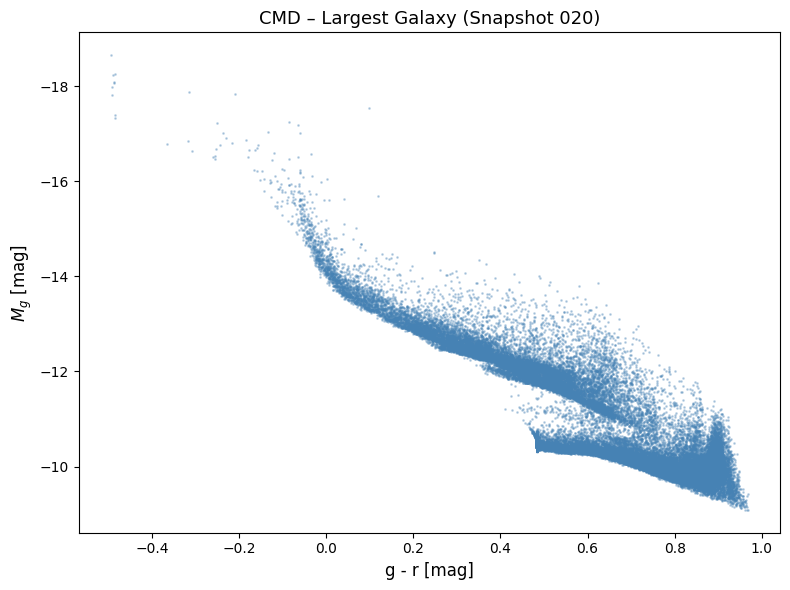

In [41]:
#=== Create CMD Plot ===#
g_r = phot["M_g"] - phot["M_r"]   # Colour index
M_g = phot["M_g"]                  # Absolute g-band magnitude

fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(g_r, M_g, s=1, alpha=0.3, c="steelblue")

ax.set_xlabel("g - r [mag]",  fontsize=12)
ax.set_ylabel("$M_g$ [mag]",  fontsize=12)
ax.set_title("CMD – Largest Galaxy (Snapshot 020)", fontsize=13)
ax.invert_yaxis()   # Bright stars on top (astronomical convention)

plt.tight_layout()
plt.show()

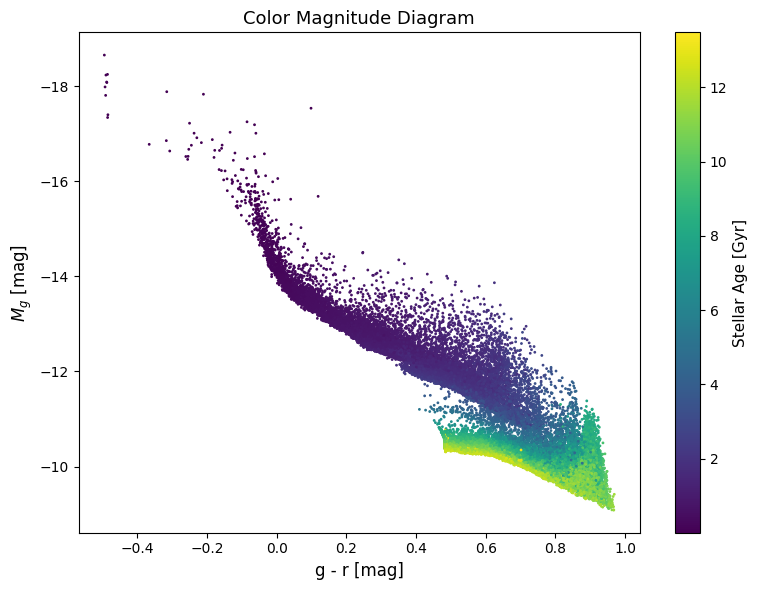

In [42]:
#=== Create CMD Plot (Age Colored) ===#
ages = gal["stellar_age"]   # Per-particle stellar ages [Gyr]

fig, ax = plt.subplots(figsize=(8, 6))

sc   = ax.scatter(g_r, M_g, s=1, alpha=1, c=ages, cmap="viridis")
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label("Stellar Age [Gyr]", fontsize=11)

ax.set_xlabel("g - r [mag]", fontsize=12)
ax.set_ylabel("$M_g$ [mag]", fontsize=12)
ax.set_title("Color Magnitude Diagram", fontsize=13)
ax.invert_yaxis()   # Bright stars on top (astronomical convention)

plt.tight_layout()
plt.show()

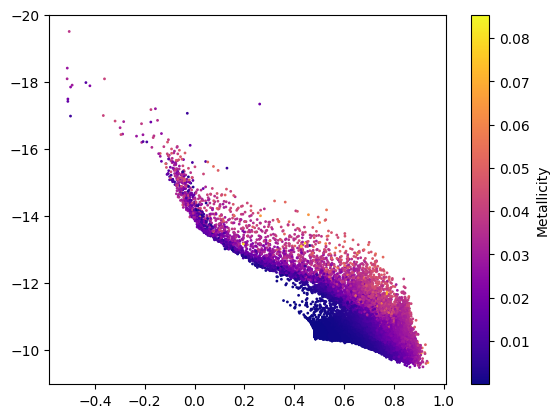

In [36]:
plt.scatter(g_r, M_g, s=1, c=gal["Z"], cmap="plasma")
plt.gca().invert_yaxis()
plt.colorbar(label="Metallicity")
plt.show()


In [37]:
def plot_position_color(gal, color, title="Positionsplot", cmap="plasma"):
    """
    Plottet x-y Positionen der Star-Particles, eingefärbt mit einer beliebigen Farbvariable.
    
    gal:   dict mit gal["pos"] (N,3)
    color: Array der Länge N (z.B. g-r, M_g, F606W-F814W, metallicity, age, ...)
    """

    x = gal["pos"][:, 0]
    y = gal["pos"][:, 1]

    plt.figure(figsize=(7, 6))
    plt.scatter(x, y, c=color, s=3, cmap=cmap, alpha=0.8)

    plt.colorbar(label="Farbwert")
    plt.xlabel("x [kpc]")
    plt.ylabel("y [kpc]")
    plt.title(title)
    plt.gca().set_aspect("equal")
    plt.tight_layout()
    plt.show()


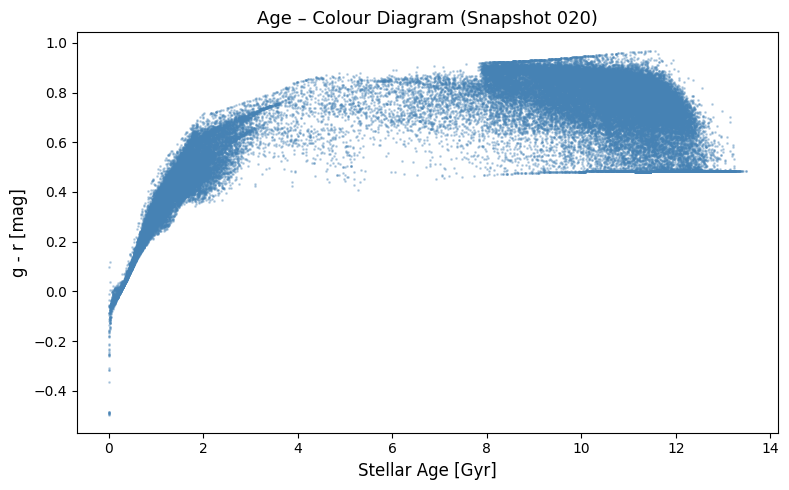

In [38]:
# =============================================================================
# Age – Colour Diagram
# =============================================================================

ages = gal["stellar_age"]           # (N,) – stellar ages [Gyr]
g_r  = phot["M_g"] - phot["M_r"]   # (N,) – g-r colour per particle

fig, ax = plt.subplots(figsize=(8, 5))

ax.scatter(ages, g_r, s=1, alpha=0.3, c="steelblue")

ax.set_xlabel("Stellar Age [Gyr]", fontsize=12)
ax.set_ylabel("g - r [mag]",       fontsize=12)
ax.set_title("Age – Colour Diagram (Snapshot 020)", fontsize=13)

plt.tight_layout()
plt.show()

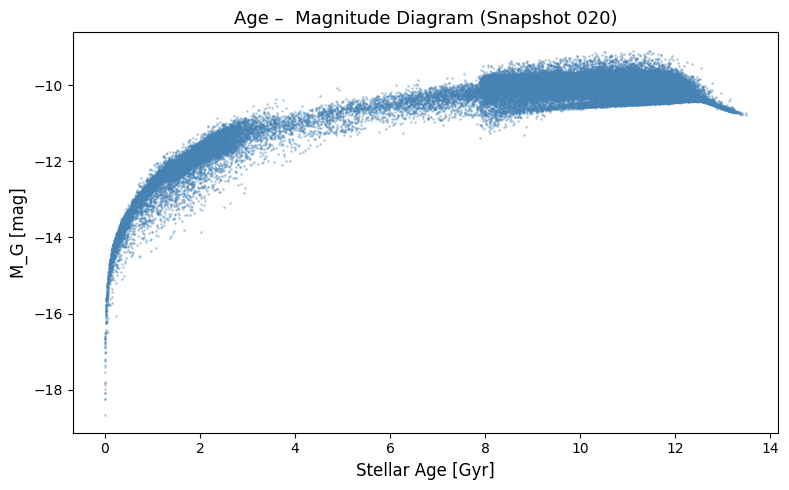

In [39]:
# =============================================================================
# Age – Colour Diagram
# =============================================================================

ages = gal["stellar_age"]           # (N,) – stellar ages [Gyr]
g_r  = phot["M_g"]  # (N,) – g-r colour per particle

fig, ax = plt.subplots(figsize=(8, 5))

ax.scatter(ages, g_r, s=1, alpha=0.3, c="steelblue")

ax.set_xlabel("Stellar Age [Gyr]", fontsize=12)
ax.set_ylabel("M_G [mag]",       fontsize=12)
ax.set_title("Age –  Magnitude Diagram (Snapshot 020)", fontsize=13)

plt.tight_layout()
plt.show()

In [75]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import binned_statistic, binned_statistic_2d

# ============================================================
# 1) Subhalo recentern
# ============================================================

def recenter_subhalo(gal):
    """
    Recentert die Sternpositionen auf das Subhalo-Zentrum.
    Nutzt den Median (robust gegen Ausreißer).
    """
    x0 = np.median(gal["pos"][:,0])
    y0 = np.median(gal["pos"][:,1])
    z0 = np.median(gal["pos"][:,2])

    gal_centered = gal.copy()
    gal_centered["pos"] = gal["pos"] - np.array([x0, y0, z0])

    return gal_centered


# ============================================================
# 2) Hilfsfunktionen
# ============================================================

def compute_color_gr(phot):
    return phot["M_g"] - phot["M_r"]

def compute_radial_profiles(gal, color):
    x, y = gal["pos"][:,0], gal["pos"][:,1]
    R = np.sqrt(x**2 + y**2)

    bins = np.linspace(0, R.max(), 30)
    centers = 0.5 * (bins[1:] + bins[:-1])

    radial_color = binned_statistic(R, color, bins=bins)[0]
    radial_age   = binned_statistic(R, gal["stellar_age"], bins=bins)[0]
    radial_Z     = binned_statistic(R, gal["Z"], bins=bins)[0]

    return centers, radial_color, radial_age, radial_Z

def compute_xy_map(gal, color, nbins=200):
    x, y = gal["pos"][:,0], gal["pos"][:,1]
    stat, xedges, yedges, _ = binned_statistic_2d(x, y, color, bins=nbins)
    return xedges, yedges, stat

def compute_RZ_map(gal, quantity, nbins_R=60, nbins_Z=60):
    x, y, z = gal["pos"][:,0], gal["pos"][:,1], gal["pos"][:,2]
    R = np.sqrt(x**2 + y**2)
    stat, R_edges, Z_edges, _ = binned_statistic_2d(R, z, quantity,
                                                    bins=[nbins_R, nbins_Z])
    return R_edges, Z_edges, stat


# ============================================================
# 3) Großes 3×4 Panel
# ============================================================

def plot_big_panel(gal, phot):
    # --- Subhalo recentern ---
    gal = recenter_subhalo(gal)

    # --- Farben ---
    color = phot["M_g"] - phot["M_r"]
    mag_g = phot["M_g"]

    x, y, z = gal["pos"][:,0], gal["pos"][:,1], gal["pos"][:,2]

    # --- Radialprofile ---
    R, rc, ra, rz = compute_radial_profiles(gal, color)

    # --- 2D Maps ---
    xedges, yedges, xy_map = compute_xy_map(gal, color)
    R_edges, Z_edges, RZ_color = compute_RZ_map(gal, color)
    _, _, RZ_age = compute_RZ_map(gal, gal["stellar_age"])
    _, _, RZ_Z   = compute_RZ_map(gal, gal["Z"])

    # --- Figure ---
    fig = plt.figure(figsize=(18, 12))
    axes = fig.subplots(3, 4)

    ax_text     = axes[0,0]
    ax_cmd      = axes[0,1]
    ax_3d       = fig.add_subplot(3,4,3, projection='3d')
    ax_edge     = axes[0,3]
    ax_heat     = axes[1,0]
    ax_rad_col  = axes[1,1]
    ax_rad_age  = axes[1,2]
    ax_rad_Z    = axes[1,3]
    ax_RZ_col   = axes[2,0]
    ax_RZ_age   = axes[2,1]
    ax_RZ_Z     = axes[2,2]
    ax_free     = axes[2,3]

    # --- Textpanel ---
    ax_text.axis("off")
    ax_text.text(0.05, 0.95,
                 "Galaxy Overview\nFarbe = g - r\nPhotometrie = FSPS\n(Recentered Subhalo)",
                 va="top", ha="left", fontsize=10)

    # --- CMD ---
    ax_cmd.scatter(color, mag_g, s=1, alpha=1.0)
    ax_cmd.set_xlabel("g - r")
    ax_cmd.set_ylabel("M_g")
    ax_cmd.set_title("CMD (g - r vs M_g)")
    ax_cmd.invert_yaxis()
    ax_cmd.grid(alpha=0.0)

    # --- 3D ---
    p3d = ax_3d.scatter(x, y, z, c=color, s=1, cmap='plasma', alpha=1.0)
    fig.colorbar(p3d, ax=ax_3d, fraction=0.03, pad=0.02, label="g - r")
    ax_3d.set_xlabel("x [kpc]")
    ax_3d.set_ylabel("y [kpc]")
    ax_3d.set_zlabel("z [kpc]")
    ax_3d.set_title("3D-Karte (g-r)")
    ax_3d.view_init(elev=30, azim=45)

    # --- Edge-on ---
    sc = ax_edge.scatter(x, z, c=color, s=1, cmap='plasma', alpha=1.0)
    fig.colorbar(sc, ax=ax_edge, fraction=0.03, pad=0.02, label="g - r")
    ax_edge.set_xlabel("x [kpc]")
    ax_edge.set_ylabel("z [kpc]")
    ax_edge.set_title("Edge-On (x–z)")

    # --- Heatmap x-y ---
    im = ax_heat.imshow(xy_map.T, origin='lower', cmap='plasma',
                        extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
                        aspect='equal')
    fig.colorbar(im, ax=ax_heat, fraction=0.03, pad=0.02, label="g - r")
    ax_heat.set_xlabel("x [kpc]")
    ax_heat.set_ylabel("y [kpc]")
    ax_heat.set_title("2D-Heatmap (x–y)")

    # --- Radialprofile ---
    ax_rad_col.plot(R, rc, lw=2)
    ax_rad_col.set_xlabel("Radius [kpc]")
    ax_rad_col.set_ylabel("g - r")
    ax_rad_col.set_title("Radiales Farbprofil")
    ax_rad_col.grid(alpha=0.3)

    ax_rad_age.plot(R, ra, lw=2, color='steelblue')
    ax_rad_age.set_xlabel("Radius [kpc]")
    ax_rad_age.set_ylabel("Age [Gyr]")
    ax_rad_age.set_title("Radiales Altersprofil")
    ax_rad_age.grid(alpha=0.3)

    ax_rad_Z.plot(R, rz, lw=2, color='darkorange')
    ax_rad_Z.set_xlabel("Radius [kpc]")
    ax_rad_Z.set_ylabel("Z")
    ax_rad_Z.set_title("Radiales Metallizitätsprofil")
    ax_rad_Z.grid(alpha=0.3)

    # --- R-z Maps ---
    extent = [R_edges[0], R_edges[-1], Z_edges[0], Z_edges[-1]]

    im1 = ax_RZ_col.imshow(RZ_color.T, origin='lower', cmap='plasma',
                           extent=extent, aspect='auto')
    fig.colorbar(im1, ax=ax_RZ_col, fraction=0.03, pad=0.02, label="g - r")
    ax_RZ_col.set_xlabel("R [kpc]")
    ax_RZ_col.set_ylabel("z [kpc]")
    ax_RZ_col.set_title("R–z Profil (g-r)")

    im2 = ax_RZ_age.imshow(RZ_age.T, origin='lower', cmap='viridis',
                           extent=extent, aspect='auto')
    fig.colorbar(im2, ax=ax_RZ_age, fraction=0.03, pad=0.02, label="Age [Gyr]")
    ax_RZ_age.set_xlabel("R [kpc]")
    ax_RZ_age.set_ylabel("z [kpc]")
    ax_RZ_age.set_title("R–z Profil (Alter)")

    im3 = ax_RZ_Z.imshow(RZ_Z.T, origin='lower', cmap='inferno',
                         extent=extent, aspect='auto')
    fig.colorbar(im3, ax=ax_RZ_Z, fraction=0.03, pad=0.02, label="Z")
    ax_RZ_Z.set_xlabel("R [kpc]")
    ax_RZ_Z.set_ylabel("z [kpc]")
    ax_RZ_Z.set_title("R–z Profil (Metallizität)")

    ax_free.axis("off")

    plt.tight_layout()
    plt.show()


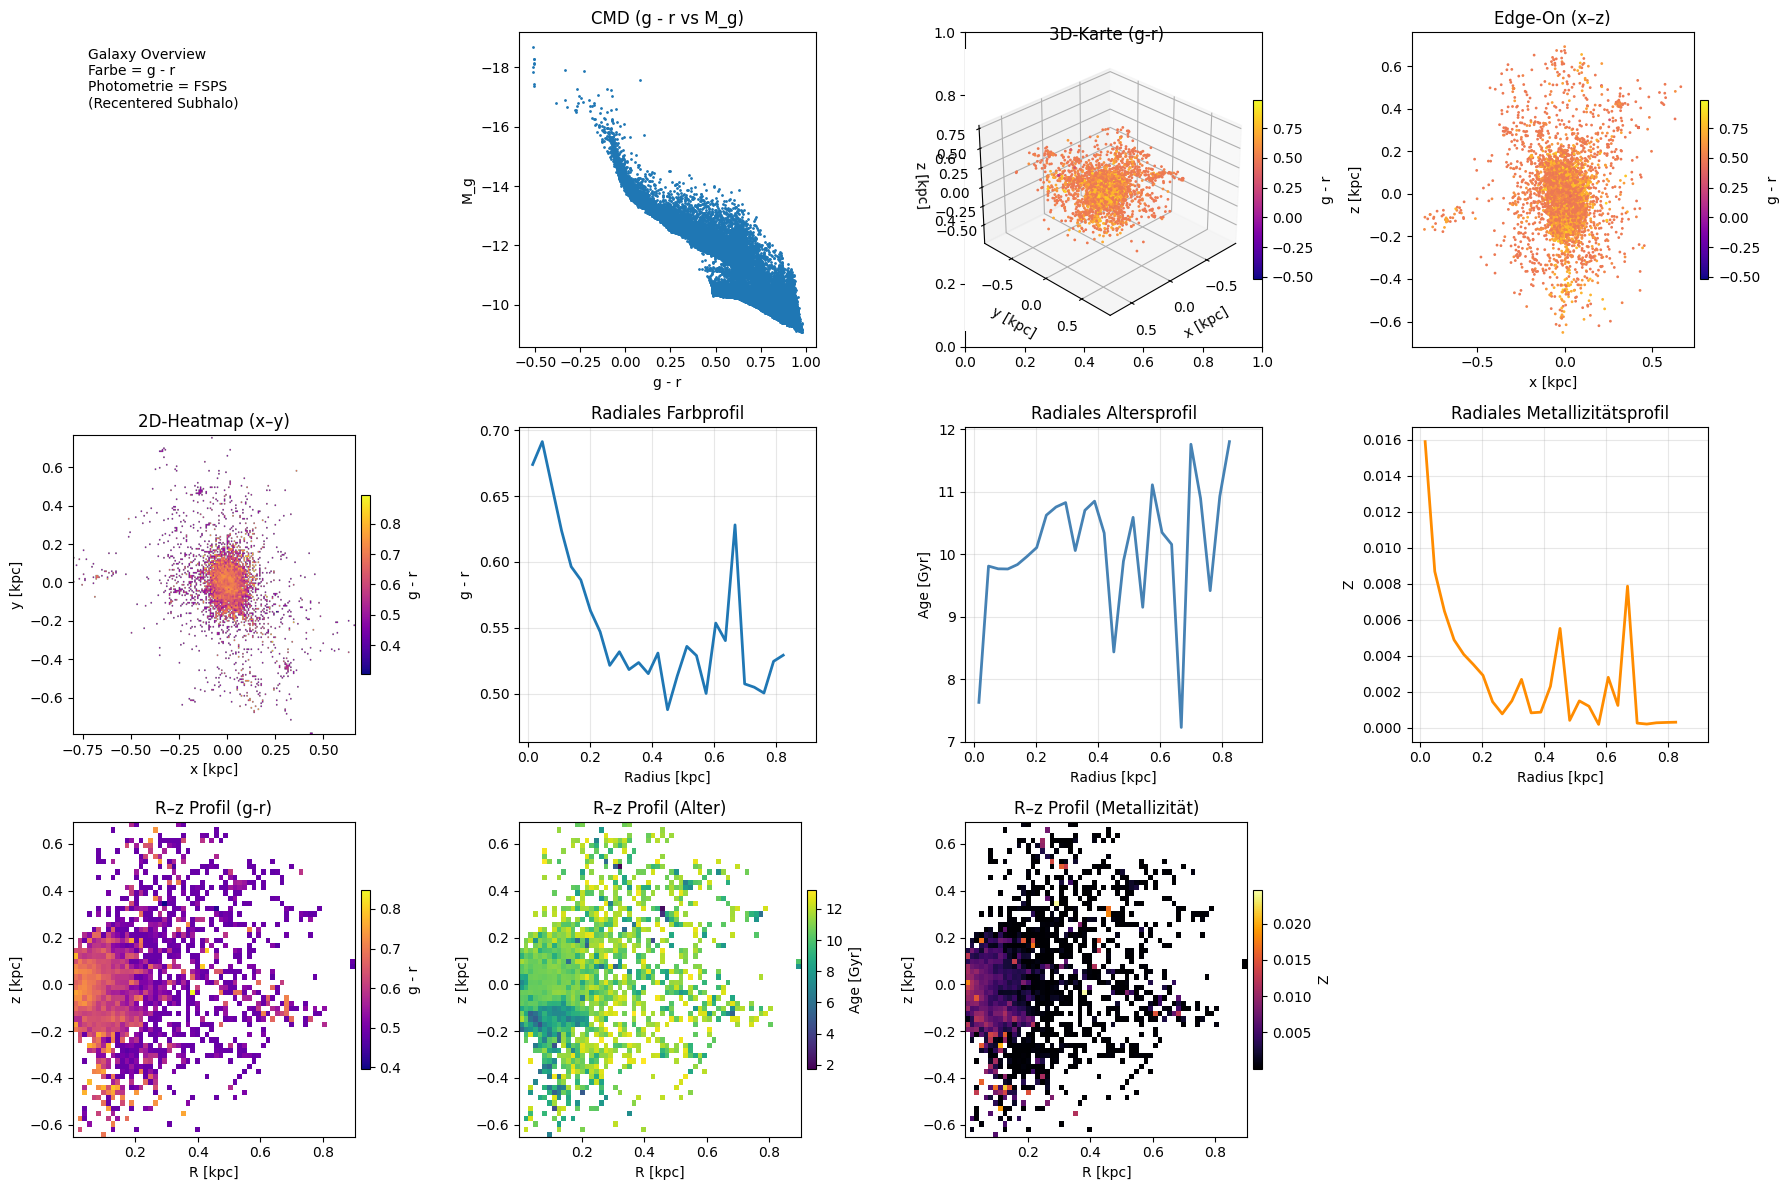

In [76]:
plot_big_panel(gal, phot)


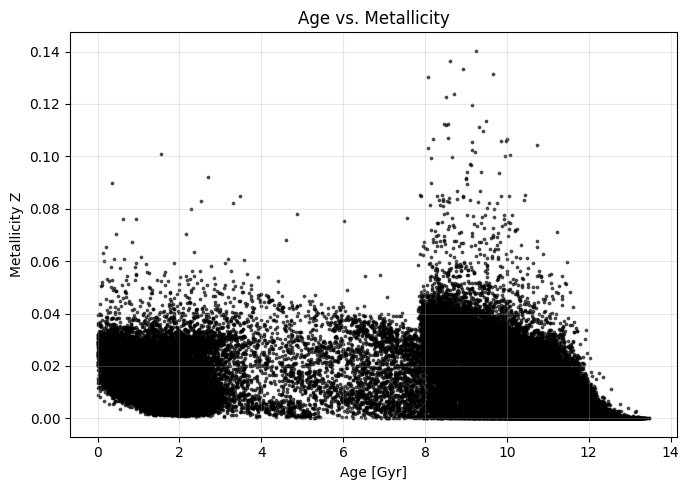

In [79]:
def plot_age_vs_metallicity(gal):
    # Subhalo recentern (optional, aber sinnvoll)
    gal = recenter_subhalo(gal)

    age = gal["stellar_age"]
    Z   = gal["Z"]

    plt.figure(figsize=(7,5))
    plt.scatter(age, Z, s=3, alpha=0.6, color="black")
    plt.xlabel("Age [Gyr]")
    plt.ylabel("Metallicity Z")
    plt.title("Age vs. Metallicity")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_age_vs_metallicity(gal)

TEST

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import subprocess

def create_cmd_video_all_subhalos_age_colored(
        gal_root,
        snapnum=20,
        variant="fsps_parsec_basel_chabrier",
        output_dir="/home/lenna/Synthesizer_Osaka/Plots/CMD",
        min_stars=1000,
        fps=5):

    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    frame_index = 0

    # Wir versuchen idx = 0, 1, 2, ... bis keiner mehr existiert
    for idx in range(5000):  # 5000 = safe upper bound
        try:
            gal = load_galaxy_by_idx(gal_root, snapnum=snapnum, idx=idx)
        except FileNotFoundError:
            break  # keine weiteren Subhalos vorhanden

        # Photometrie laden
        try:
            phot = gal["sed"]["FSPS"][variant]["photometry"]
        except KeyError:
            print(f"Subhalo {idx}: Photometrie '{variant}' nicht gefunden – übersprungen.")
            continue

        # Anzahl Sterne prüfen
        N = len(phot["M_g"])
        if N < min_stars:
            #print(f"Subhalo {idx}: nur {N} Sterne – übersprungen.")
            continue

        print(f"Subhalo {idx}: {N} Sterne – CMD mit Age-Coloring wird erzeugt.")

        # CMD-Daten
        g = phot["M_g"]
        r = phot["M_r"]
        color = g - r
        mag = r

        # Age-Feld aus gal
        ages = gal["stellar_age"]  # in Gyr

        # Plot
        plt.figure(figsize=(6, 6))
        sc = plt.scatter(color, mag, s=1, c=ages, cmap="plasma")
        plt.gca().invert_yaxis()
        plt.xlabel("g - r")
        plt.ylabel("r")
        plt.title(f"Subhalo idx={idx}  (N={N}) – Age Coloring")

        # Colorbar
        cbar = plt.colorbar(sc)
        cbar.set_label("Age [Gyr]")

        # PNG speichern
        png_path = output_dir / f"cmd_{frame_index:04d}.png"
        plt.savefig(png_path, dpi=150)
        plt.close()

        print(f"Gespeichert: {png_path}")
        frame_index += 1

    # Wenn keine Frames erzeugt wurden
    if frame_index == 0:
        print("Keine Subhalos über dem Grenzwert gefunden.")
        return

    # Video erzeugen
    print("Erzeuge Video...")

    input_pattern = str(output_dir / "cmd_%04d.png")
    output_video = str(output_dir / "cmd_video.mp4")

    cmd = [
        "ffmpeg",
        "-framerate", str(fps),
        "-i", input_pattern,
        "-pix_fmt", "yuv420p",
        output_video
    ]

    subprocess.run(cmd, check=True)
    print(f"Video erfolgreich erzeugt: {output_video}")


In [33]:
create_cmd_video_all_subhalos_age_colored(gal_root)


Subhalo 0: 72072 Sterne – CMD mit Age-Coloring wird erzeugt.
Gespeichert: /home/lenna/Synthesizer_Osaka/Plots/CMD/cmd_0000.png
Subhalo 1: nur 565 Sterne – übersprungen.
Subhalo 2: 32608 Sterne – CMD mit Age-Coloring wird erzeugt.
Gespeichert: /home/lenna/Synthesizer_Osaka/Plots/CMD/cmd_0001.png
Subhalo 3: 29342 Sterne – CMD mit Age-Coloring wird erzeugt.
Gespeichert: /home/lenna/Synthesizer_Osaka/Plots/CMD/cmd_0002.png
Subhalo 4: 41227 Sterne – CMD mit Age-Coloring wird erzeugt.
Gespeichert: /home/lenna/Synthesizer_Osaka/Plots/CMD/cmd_0003.png
Subhalo 5: 40914 Sterne – CMD mit Age-Coloring wird erzeugt.
Gespeichert: /home/lenna/Synthesizer_Osaka/Plots/CMD/cmd_0004.png
Subhalo 6: 20511 Sterne – CMD mit Age-Coloring wird erzeugt.
Gespeichert: /home/lenna/Synthesizer_Osaka/Plots/CMD/cmd_0005.png
Subhalo 7: 25490 Sterne – CMD mit Age-Coloring wird erzeugt.
Gespeichert: /home/lenna/Synthesizer_Osaka/Plots/CMD/cmd_0006.png
Subhalo 8: 34521 Sterne – CMD mit Age-Coloring wird erzeugt.
Gespeich

ffmpeg version 8.0.1 Copyright (c) 2000-2025 the FFmpeg developers
  built with gcc 14.3.0 (conda-forge gcc 14.3.0-16)
  configuration: --prefix=/home/lenna/miniconda3/envs/FSPS_Osaka --cc=/home/conda/feedstock_root/build_artifacts/ffmpeg_1769712549653/_build_env/bin/x86_64-conda-linux-gnu-cc --cxx=/home/conda/feedstock_root/build_artifacts/ffmpeg_1769712549653/_build_env/bin/x86_64-conda-linux-gnu-c++ --nm=/home/conda/feedstock_root/build_artifacts/ffmpeg_1769712549653/_build_env/bin/x86_64-conda-linux-gnu-nm --ar=/home/conda/feedstock_root/build_artifacts/ffmpeg_1769712549653/_build_env/bin/x86_64-conda-linux-gnu-ar --disable-doc --enable-openssl --enable-demuxer=dash --enable-hardcoded-tables --enable-libfreetype --enable-libharfbuzz --enable-libfontconfig --enable-libopenh264 --enable-libdav1d --disable-gnutls --enable-libvpx --enable-libass --enable-pthreads --enable-alsa --enable-libpulse --enable-libvpl --enable-vaapi --enable-libopenvino --enable-gpl --enable-libx264 --enable-l

Video erfolgreich erzeugt: /home/lenna/Synthesizer_Osaka/Plots/CMD/cmd_video.mp4


[out#0/mp4 @ 0x5dbde8bdee40] video:3762KiB audio:0KiB subtitle:0KiB other streams:0KiB global headers:0KiB muxing overhead: 0.076754%
frame=  173 fps= 57 q=-1.0 Lsize=    3765KiB time=00:00:34.20 bitrate= 901.9kbits/s speed=11.2x elapsed=0:00:03.05    
[libx264 @ 0x5dbde8bdfd00] frame I:2     Avg QP: 8.47  size: 43458
[libx264 @ 0x5dbde8bdfd00] frame P:46    Avg QP:20.65  size: 21392
[libx264 @ 0x5dbde8bdfd00] frame B:125   Avg QP:24.07  size: 22247
[libx264 @ 0x5dbde8bdfd00] consecutive B-frames:  1.7%  2.3% 10.4% 85.5%
[libx264 @ 0x5dbde8bdfd00] mb I  I16..4: 69.2% 11.5% 19.3%
[libx264 @ 0x5dbde8bdfd00] mb P  I16..4:  0.8%  5.3%  7.0%  P16..4:  4.5%  1.4%  0.9%  0.0%  0.0%    skip:80.0%
[libx264 @ 0x5dbde8bdfd00] mb B  I16..4:  0.3%  1.4%  6.8%  B16..8: 11.3%  1.7%  1.0%  direct: 0.3%  skip:77.2%  L0:53.4% L1:44.5% BI: 2.1%
[libx264 @ 0x5dbde8bdfd00] 8x8 transform intra:23.6% inter:7.4%
[libx264 @ 0x5dbde8bdfd00] coded y,uvDC,uvAC intra: 51.5% 58.1% 57.9% inter: 2.3% 2.7% 2.6%
[libx2